In [ ]:
# [CELL 0]
# LastWave-style plotting utilities — imported from wtmm package

import numpy as np
import matplotlib.pyplot as plt
from wtmm.colormaps import (
    lastwave_colormap,
    lastwave_grey_colormap,
    lastwave_b2r_colormap,
    scalogram_lastwave,
)

_lw_cmap = lastwave_colormap(256)
_lw_grey = lastwave_grey_colormap(256)
_lw_b2r = lastwave_b2r_colormap(256)
try:
    plt.colormaps.register(_lw_cmap)
    plt.colormaps.register(_lw_grey)
    plt.colormaps.register(_lw_b2r)
except ValueError:
    pass  # already registered

print("LastWave plotting utilities loaded:")
print("  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'")
print("  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)")
print(f"              norm_mode='lglobal' (default) | 'global' | 'signedglobal'")
print(f"  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)")

LastWave plotting utilities loaded:
  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'
  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)
              norm_mode='lglobal' (default) | 'global' | 'signedglobal'
  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)


** Warning : Unable to read history file '/dev/null'



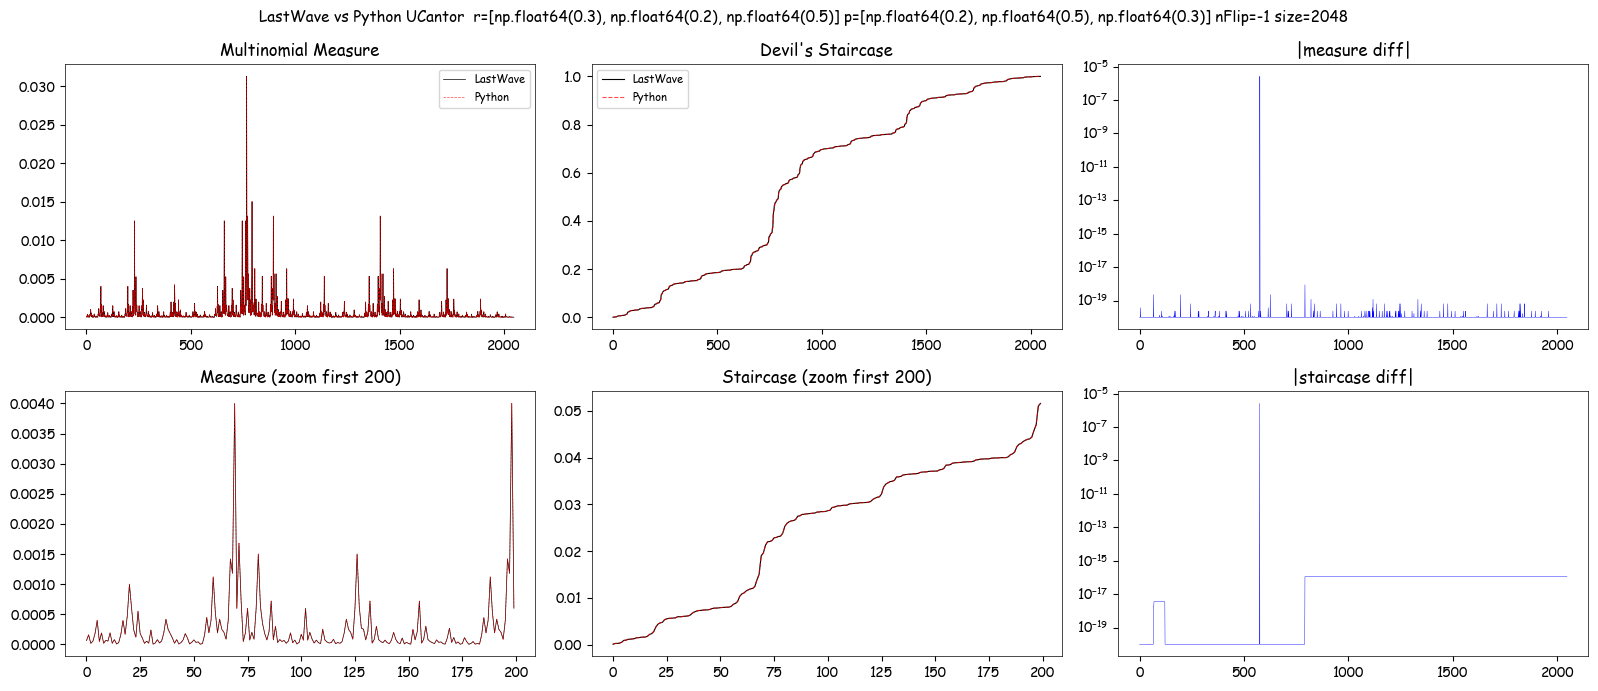

Max |measure diff|:   2.59e-06
Max |staircase diff|: 2.59e-06
Staircase range LW:   [0.000064, 1.000000]
Staircase range Py:   [0.000064, 1.000000]


In [ ]:
# [CELL 1] LastWave ground truth — Step 1: Inhomogeneous devil's staircase (LastWave vs Python)
import ctypes, ctypes.util, numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Force reload the dylib (kernel may cache old version)
_lw_path = './liblastwave_wrapper.dylib'
try:
    ctypes.cdll.LoadLibrary(_lw_path)
except:
    pass
lib = ctypes.CDLL(_lw_path)

lib.lw_init.restype = ctypes.c_int
lib.lw_ucantor.restype = ctypes.c_int
lib.lw_ucantor.argtypes = [ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.c_int, ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double)]
lib.lw_cleanup.restype = None
lib.lw_get_error.restype = ctypes.c_char_p
lib.lw_eval_wavelet.restype = ctypes.c_int
lib.lw_get_wavelet_domain.restype = ctypes.c_int

c_double_p = ctypes.POINTER(ctypes.c_double)

ret = lib.lw_init()
assert ret == 0, f"lw_init failed: {lib.lw_get_error()}"

# ── DemoWTMM1DDevilStair parameters ──
SIZE = 2048
r = np.array([0.3, 0.2, 0.5], dtype=np.float64)
p = np.array([0.2, 0.5, 0.3], dtype=np.float64)
nFlip = -1  # no flip (matches C_UCantor doing nFlip-- from 0)

# ── LastWave UCantor ──
lw_measure = np.zeros(SIZE, dtype=np.float64)
ret = lib.lw_ucantor(SIZE, r.ctypes.data_as(c_double_p),
                      p.ctypes.data_as(c_double_p), 3, nFlip,
                      lw_measure.ctypes.data_as(c_double_p))
assert ret == 0, f"lw_ucantor failed: {lib.lw_get_error()}"
lw_staircase = np.cumsum(lw_measure)

# ── Python UCantor (matches LastWave's C arithmetic exactly) ──
def ucantor(size, r, p, nFlip=-1):
    dx = 1.0 / size
    signal = np.zeros(size)
    r = list(r)
    p = list(p)
    n = len(r)
    # Iterative DFS matching C's recursive UCantor exactly:
    #   l accumulates across siblings: l += (right-left)*r[i]
    #   ISig: (int)(left / dx)    (since x0=0)
    #   termination: fabs(right-left) <= dx
    stack = [(0.0, 1.0, 1.0)]  # (left, right, proba)
    while stack:
        left, right, proba = stack.pop()
        if abs(right - left) <= dx:
            i = int(left / dx)
            if i < 0: i = 0
            elif i >= size: i = size - 1
            signal[i] += proba
            continue
        # Accumulate l across siblings, matching C
        span = right - left
        l = left
        for i in range(n):
            child_proba = proba * p[i]
            if i == nFlip:
                stack.append((l + span * r[i], l, child_proba))
            else:
                stack.append((l, l + span * r[i], child_proba))
            l += span * r[i]
    return signal

py_measure = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)
py_staircase = np.cumsum(py_measure)

# ── Compare ──
measure_diff = np.abs(lw_measure - py_measure)
stair_diff = np.abs(lw_staircase - py_staircase)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

axes[0, 0].plot(lw_measure, 'k-', lw=0.5, label='LastWave')
axes[0, 0].plot(py_measure, 'r--', lw=0.5, alpha=0.7, label='Python')
axes[0, 0].set_title('Multinomial Measure')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(lw_staircase, 'k-', lw=0.8, label='LastWave')
axes[0, 1].plot(py_staircase, 'r--', lw=0.8, alpha=0.7, label='Python')
axes[0, 1].set_title("Devil's Staircase")
axes[0, 1].legend(fontsize=8)

axes[0, 2].semilogy(measure_diff + 1e-20, 'b-', lw=0.3)
axes[0, 2].set_title('|measure diff|')

axes[1, 0].plot(lw_measure[:200], 'k-', lw=0.5)
axes[1, 0].plot(py_measure[:200], 'r--', lw=0.5, alpha=0.7)
axes[1, 0].set_title('Measure (zoom first 200)')

axes[1, 1].plot(lw_staircase[:200], 'k-', lw=0.8)
axes[1, 1].plot(py_staircase[:200], 'r--', lw=0.8, alpha=0.7)
axes[1, 1].set_title('Staircase (zoom first 200)')

axes[1, 2].semilogy(stair_diff + 1e-20, 'b-', lw=0.3)
axes[1, 2].set_title('|staircase diff|')

plt.suptitle(f'LastWave vs Python UCantor  r={list(r)} p={list(p)} nFlip={nFlip} size={SIZE}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Max |measure diff|:   {measure_diff.max():.2e}')
print(f'Max |staircase diff|: {stair_diff.max():.2e}')
print(f'Staircase range LW:   [{lw_staircase.min():.6f}, {lw_staircase.max():.6f}]')
print(f'Staircase range Py:   [{py_staircase.min():.6f}, {py_staircase.max():.6f}]')

Start octave 1.........
Start octave 2.........
Start octave 3.........
Start octave 4.........
Start octave 5.........


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_43282/1717371640.py:83: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()
/Users/amasaryk/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


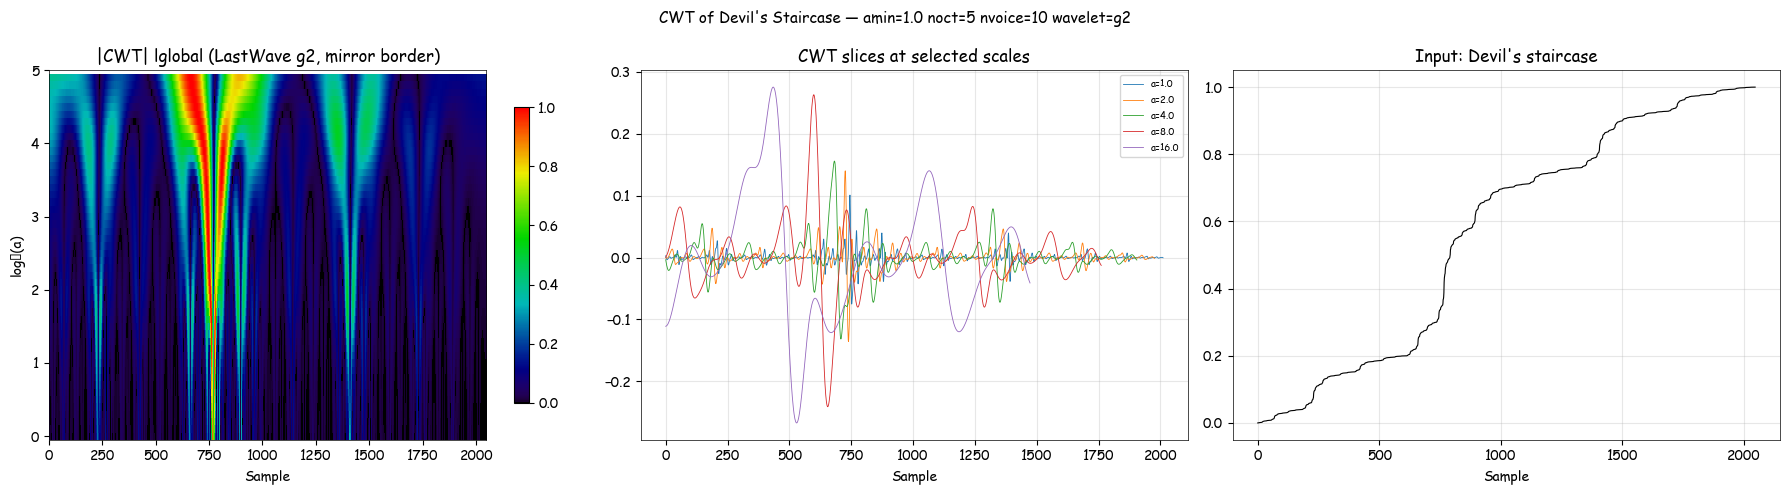

Scales: 50 total, range [1.00, 29.86]
  scale  0 (a=   1.00): valid range [18, 2029]
  scale 10 (a=   2.00): valid range [35, 2012]
  scale 20 (a=   4.00): valid range [71, 1976]
  scale 30 (a=   8.00): valid range [143, 1904]
  scale 40 (a=  16.00): valid range [287, 1760]


In [ ]:
# [CELL 2]
# LastWave ground truth — Step 2: CWT of inhomogeneous Cantor measure via LastWave
#
# DemoWTMM1DDevilStair params: amin=1.0, omax=5, nvoice=10, wavelet='g2', border='mir'
# The input is the devil's staircase (integrated measure) from cell 0.

# ── CWT setup ──
lib.lw_cwtd.restype = ctypes.c_int
lib.lw_cwtd.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # signal_in
    ctypes.c_int,                      # size
    ctypes.c_double,                   # a_min
    ctypes.c_int,                      # n_oct
    ctypes.c_int,                      # n_voice
    ctypes.c_char_p,                   # wavelet_name
    ctypes.c_double,                   # expo
    ctypes.c_int,                      # border_type
    ctypes.POINTER(ctypes.c_double),   # coeffs_out
    ctypes.POINTER(ctypes.c_int),      # firstp_out
    ctypes.POINTER(ctypes.c_int),      # lastp_out
]

a_min   = 1.0
n_oct   = 5
n_voice = 10
wavelet = b'g2'
expo    = -1.0
border  = 1       # CV_MIRROR (enum: CV_PERIODIC=0, CV_MIRROR=1, CV_PADDING=2, CV_0_PADDING=3)

n_scales = n_oct * n_voice
coeffs  = np.zeros(n_scales * SIZE, dtype=np.float64)
firstp  = np.zeros(n_scales, dtype=np.int32)
lastp   = np.zeros(n_scales, dtype=np.int32)

# CWT of the devil's staircase (= cumsum of measure), matching the demo's "0w = prim(0w)"
ret = lib.lw_cwtd(
    lw_staircase.ctypes.data_as(c_double_p), SIZE,
    ctypes.c_double(a_min), n_oct, n_voice,
    wavelet, ctypes.c_double(expo), border,
    coeffs.ctypes.data_as(c_double_p),
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
assert ret == 0, f"lw_cwtd failed: {lib.lw_get_error()}"

cwt = coeffs.reshape(n_scales, SIZE)

# ── Scale axis ──
factor = 2.0 ** (1.0 / n_voice)
scales = a_min * factor ** np.arange(n_scales)
log2_scales = np.log2(scales)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Scalogram (LastWave lglobal normalization — per-scale-line, no log)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('|CWT| lglobal (LastWave g2, mirror border)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# CWT at a few selected scales
sel = [0, n_voice, 2*n_voice, 3*n_voice, 4*n_voice]
for s in sel:
    fp, lp = firstp[s], lastp[s]
    axes[1].plot(cwt[s, fp:lp+1], lw=0.6, label=f'a={scales[s]:.1f}')
axes[1].set_title('CWT slices at selected scales')
axes[1].set_xlabel('Sample')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Devil's staircase for reference
axes[2].plot(lw_staircase, 'k-', lw=0.8)
axes[2].set_title("Input: Devil's staircase")
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"CWT of Devil's Staircase — amin={a_min} noct={n_oct} nvoice={n_voice} wavelet=g2", fontsize=11)
plt.tight_layout()
plt.show()

# ── Valid range info ──
print(f'Scales: {n_scales} total, range [{scales[0]:.2f}, {scales[-1]:.2f}]')
for s in sel:
    print(f'  scale {s:2d} (a={scales[s]:7.2f}): valid range [{firstp[s]}, {lastp[s]}]')

Total extrema found: 3645
Extracted 3645 extrema across 50 scales


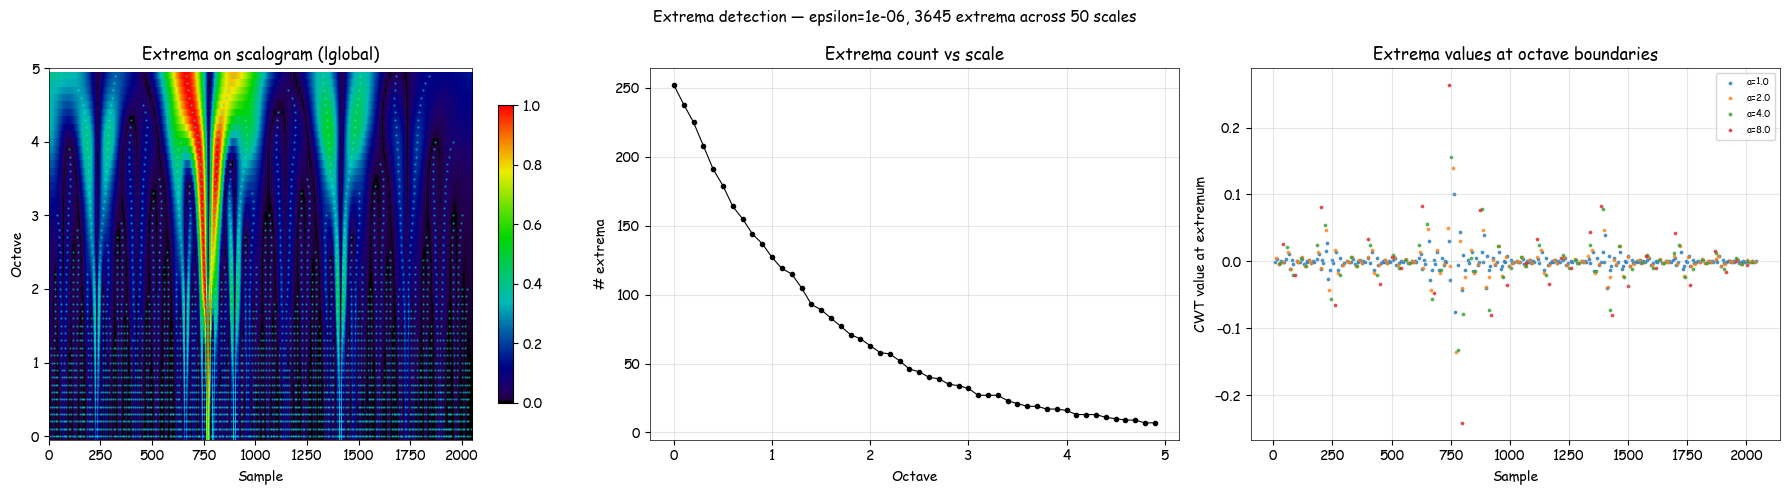


   Scale   Octave  # ext
--------------------------
    1.00    0.000    252
    2.00    1.000    127
    4.00    2.000     63
    8.00    3.000     32
   16.00    4.000     16


In [ ]:
# [CELL 3]
# LastWave ground truth — Step 3: Extrema detection on CWT
#
# DemoWTMM1DDevilStair does:
#   extrema w          (default epsilon=1e-6, interpolated)
#   chainmax w.extrep 1
#
# lw_compute_extrema runs ComputeExtrep on the global wtrans from the previous CWT.
# Then we extract extrema positions & values at each scale for visualization.

# ── Declare function signatures ──
lib.lw_compute_extrema.restype = ctypes.c_int
lib.lw_compute_extrema.argtypes = [ctypes.c_double]

lib.lw_get_extrema_count.restype = ctypes.c_int
lib.lw_get_extrema_count.argtypes = [ctypes.c_int, ctypes.c_int]

lib.lw_get_extrema_at_scale.restype = ctypes.c_int
lib.lw_get_extrema_at_scale.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.c_int,
]

lib.lw_get_n_oct.restype = ctypes.c_int
lib.lw_get_n_voice.restype = ctypes.c_int

# ── Compute extrema ──
epsilon = 1e-6  # LastWave default
nb_ext = lib.lw_compute_extrema(ctypes.c_double(epsilon))
assert nb_ext >= 0, f"lw_compute_extrema failed: {lib.lw_get_error()}"
print(f"Total extrema found: {nb_ext}")

# ── Extract extrema at every scale ──
ext_data = {}  # (octave, voice) -> (positions, values)
total = 0
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        count = lib.lw_get_extrema_count(o, v)
        if count <= 0:
            continue
        pos = np.zeros(count, dtype=np.float64)
        val = np.zeros(count, dtype=np.float64)
        got = lib.lw_get_extrema_at_scale(
            o, v,
            pos.ctypes.data_as(c_double_p),
            val.ctypes.data_as(c_double_p),
            count,
        )
        ext_data[(o, v)] = (pos[:got], val[:got])
        total += got

print(f"Extracted {total} extrema across {len(ext_data)} scales")

# ── Plot: extrema overlaid on scalogram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel 1: scalogram with extrema scatter (LastWave lglobal)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
# Overlay extrema
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    log2_a = log2_scales[scale_idx]
    axes[0].scatter(pos, np.full_like(pos, log2_a), s=0.3, c='cyan', alpha=0.5)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Octave')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('Extrema on scalogram (lglobal)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Panel 2: extrema count vs scale
ext_counts = np.zeros(n_scales, dtype=int)
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    ext_counts[scale_idx] = len(pos)
axes[1].plot(log2_scales, ext_counts, 'k.-', lw=0.8)
axes[1].set_xlabel('Octave')
axes[1].set_ylabel('# extrema')
axes[1].set_title('Extrema count vs scale')
axes[1].grid(True, alpha=0.3)

# Panel 3: extrema at a few selected scales
sel_scales = [(1, 0), (2, 0), (3, 0), (4, 0)]
for (o, v) in sel_scales:
    if (o, v) in ext_data:
        pos, val = ext_data[(o, v)]
        scale_idx = (o - 1) * n_voice + v
        axes[2].scatter(pos, val, s=3, label=f'a={scales[scale_idx]:.1f}', alpha=0.7)
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('CWT value at extremum')
axes[2].set_title('Extrema values at octave boundaries')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Extrema detection — epsilon={epsilon}, {total} extrema across {n_scales} scales', fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"\n{'Scale':>8} {'Octave':>8} {'# ext':>6}")
print('-' * 26)
for s in range(0, n_scales, n_voice):
    o = s // n_voice + 1
    v = s % n_voice
    c = ext_counts[s]
    print(f'{scales[s]:8.2f} {log2_scales[s]:8.3f} {c:6d}')

ChainDelete removed 0 unchained extrema
Chains remaining: 252
Extracted 252 chains, lengths: min=1, max=50, median=11


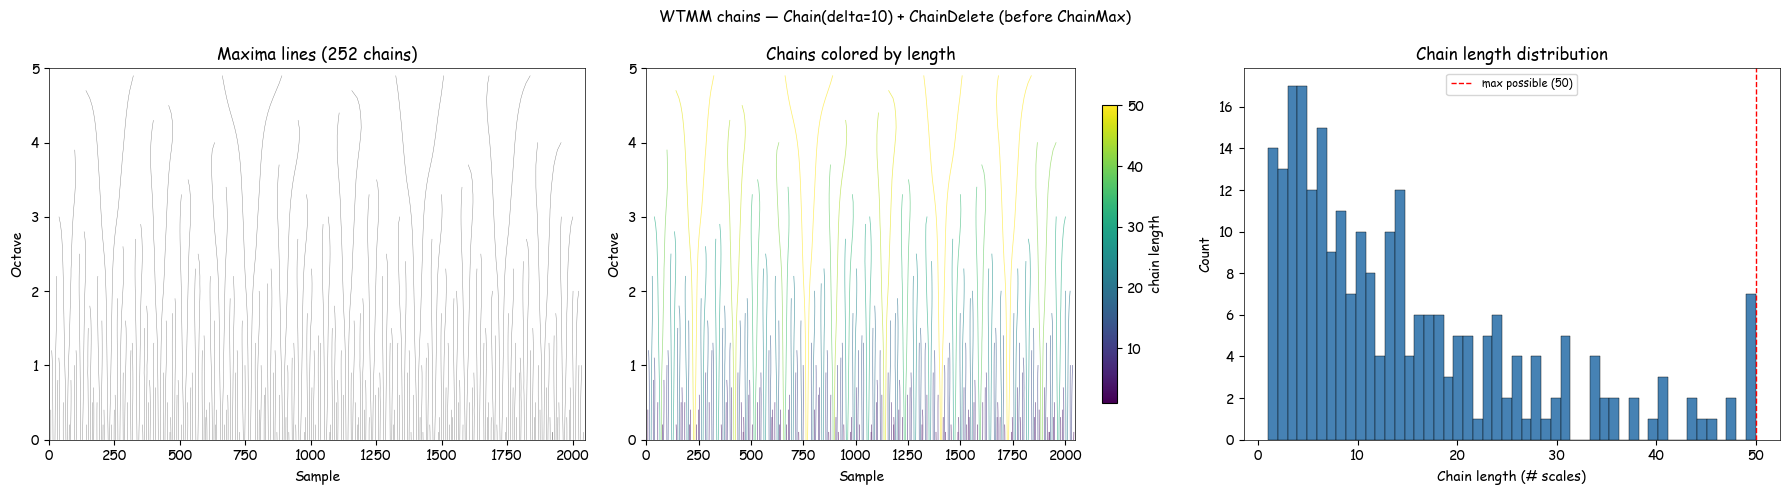

In [ ]:
# [CELL 4]
# LastWave ground truth — Step 3: Chain + ChainDelete + plot maxima lines
#
# Chain() builds linked lists via coarser/finer pointers.
# ChainDelete() prunes extrema not part of any chain.
# ChainMax is deferred to a later cell so we can compare before/after.

# ── Declare signatures ──
lib.lw_chain.restype = ctypes.c_int
lib.lw_chain.argtypes = [ctypes.c_double]

lib.lw_chain_delete.restype = ctypes.c_int
lib.lw_chain_delete.argtypes = []

lib.lw_chain_max.restype = ctypes.c_int
lib.lw_chain_max.argtypes = [ctypes.c_double]

lib.lw_get_num_chains.restype = ctypes.c_int
lib.lw_get_num_chains.argtypes = []

lib.lw_get_chain.restype = ctypes.c_int
lib.lw_get_chain.argtypes = [
    ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int), ctypes.c_int,
]

def extract_chains():
    """Extract all chains from the current extrep."""
    nc = lib.lw_get_num_chains()
    max_len = n_scales + 1
    result = []
    for ci in range(nc):
        abs_buf = np.zeros(max_len, dtype=np.float64)
        ord_buf = np.zeros(max_len, dtype=np.float64)
        scl_buf = np.zeros(max_len, dtype=np.int32)
        length = lib.lw_get_chain(
            ci,
            abs_buf.ctypes.data_as(c_double_p),
            ord_buf.ctypes.data_as(c_double_p),
            scl_buf.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
            max_len,
        )
        if length > 0:
            result.append({
                'x': abs_buf[:length].copy(),
                'val': ord_buf[:length].copy(),
                'scale_idx': scl_buf[:length].copy(),
                'log2_a': np.log2(a_min) + scl_buf[:length] / n_voice,
            })
    return result

# ── Build chains ──
ret = lib.lw_chain(ctypes.c_double(10.0))   # delta=10 (default)
assert ret == 0, f"lw_chain failed: {lib.lw_get_error()}"

deleted = lib.lw_chain_delete()
print(f"ChainDelete removed {deleted} unchained extrema")

n_chains = lib.lw_get_num_chains()
print(f"Chains remaining: {n_chains}")

# ── Extract BEFORE chainmax ──
chains = extract_chains()

print(f"Extracted {len(chains)} chains, lengths: min={min(len(c['x']) for c in chains)}, "
      f"max={max(len(c['x']) for c in chains)}, "
      f"median={np.median([len(c['x']) for c in chains]):.0f}")

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes[:2]:
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, n_oct)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Octave')
    ax.set_yticks(range(0, n_oct + 1))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

for ch in chains:
    axes[0].plot(ch['x'], ch['log2_a'], 'k-', lw=0.3, alpha=0.5)
axes[0].set_title(f'Maxima lines ({len(chains)} chains)')

lengths = np.array([len(c['x']) for c in chains])
norm = plt.Normalize(lengths.min(), lengths.max())
cmap = plt.cm.viridis
for ch in chains:
    color = cmap(norm(len(ch['x'])))
    axes[1].plot(ch['x'], ch['log2_a'], '-', color=color, lw=0.5, alpha=0.7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=axes[1], label='chain length', shrink=0.8)
axes[1].set_title('Chains colored by length')

axes[2].hist(lengths, bins=50, color='steelblue', edgecolor='k', lw=0.3)
axes[2].set_xlabel('Chain length (# scales)')
axes[2].set_ylabel('Count')
axes[2].set_title('Chain length distribution')
axes[2].axvline(n_scales, color='r', ls='--', lw=1, label=f'max possible ({n_scales})')
axes[2].legend(fontsize=8)

plt.suptitle(f"WTMM chains — Chain(delta=10) + ChainDelete (before ChainMax)", fontsize=11)
plt.tight_layout()
plt.show()

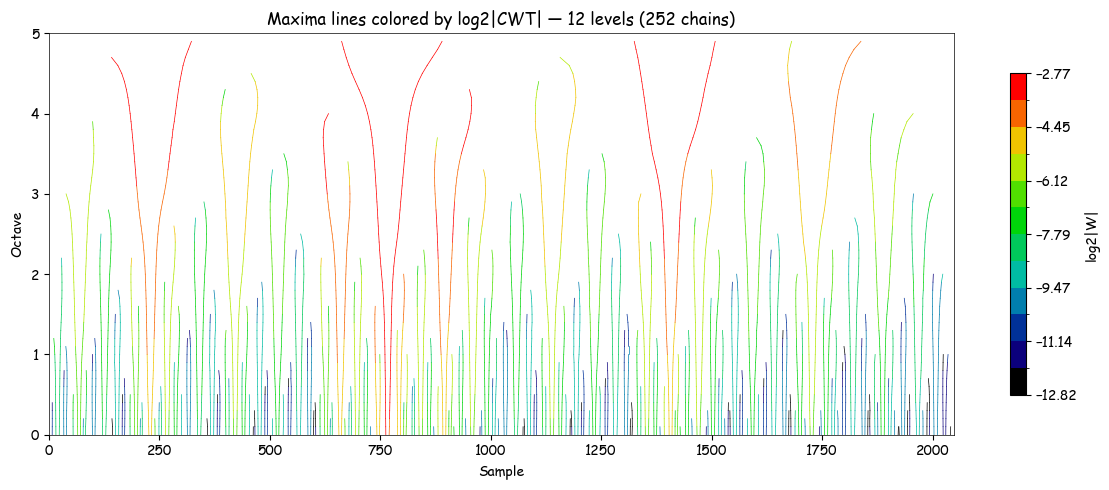

In [ ]:
# [CELL 5]
# Chains colored by log2|ordinate| (lastwave colormap, discretized)
N_COLORS = 12  # ← change this to set number of discrete color bins

fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains])
vmin, vmax = np.percentile(all_log2_vals, [2, 98])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W|', shrink=0.8)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines colored by log2|CWT| — {N_COLORS} levels ({len(chains)} chains)')
plt.tight_layout(); plt.show()

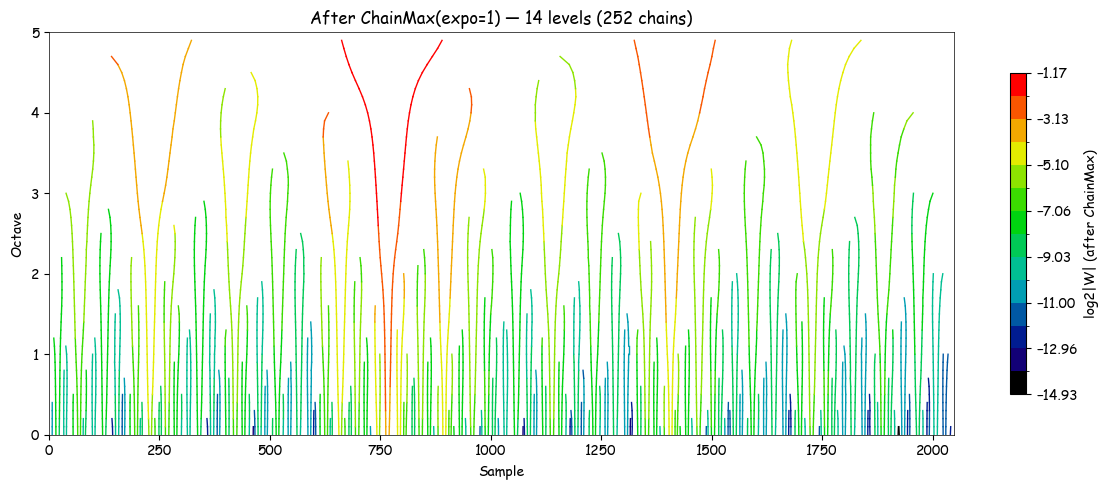

In [ ]:
# [CELL 6]
# Chains after ChainMax(expo=1) — colored by log2|ordinate| (lastwave colormap)
# ChainMax replaces each ordinate with the scale-adaptive max along the chain.
# Compare with cell 4 to see the difference.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14

ret = lib.lw_chain_max(ctypes.c_double(1.0))
assert ret == 0, f"lw_chain_max failed: {lib.lw_get_error()}"

chains_cm = extract_chains()

fig, ax = plt.subplots(figsize=(12, 5))
all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains_cm])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains_cm:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W| (after ChainMax)', shrink=0.8)

# Tight margins: bottom and sides flush, keep top gap
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — {N_COLORS} levels ({len(chains_cm)} chains)')

# Thin frames
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'  # reset after

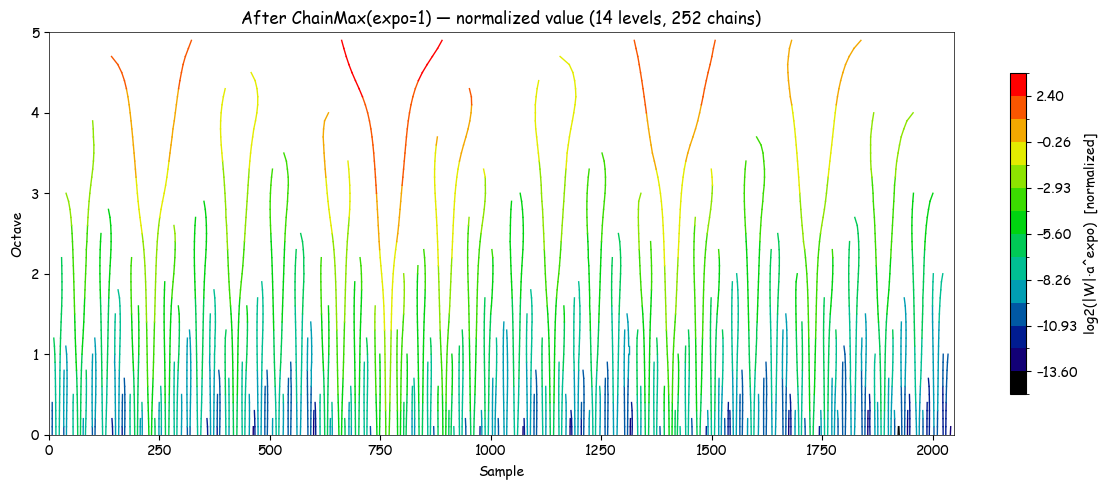

In [ ]:
# [CELL 7]
# Chains after ChainMax(expo=1) — colored by NORMALIZED value log2(|W|·a^expo)
# ChainMax guarantees monotonicity of the normalized value |W|·a^expo along each chain
# (non-increasing from fine→coarse). If ChainMax worked, each chain should appear
# as a single color or transition smoothly from warm (fine) to cool (coarse).

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14
expo = 1.0

fig, ax = plt.subplots(figsize=(12, 5))

# Compute normalized values: |ordinate| * a^expo = |ordinate| * a_min * 2^(expo * scale_idx / n_voice)
all_norm_vals = []
for ch in chains_cm:
    norm_val = np.log2(np.abs(ch['val']) + 1e-300) + expo * ch['scale_idx'] / n_voice + np.log2(a_min)
    all_norm_vals.append(norm_val)

all_norm_concat = np.concatenate(all_norm_vals)
vmin, vmax = np.percentile(all_norm_concat, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

for ch, nv in zip(chains_cm, all_norm_vals):
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(nv[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2(|W|·a^expo)  [normalized]', shrink=0.8)

ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — normalized value ({N_COLORS} levels, {len(chains_cm)} chains)')

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

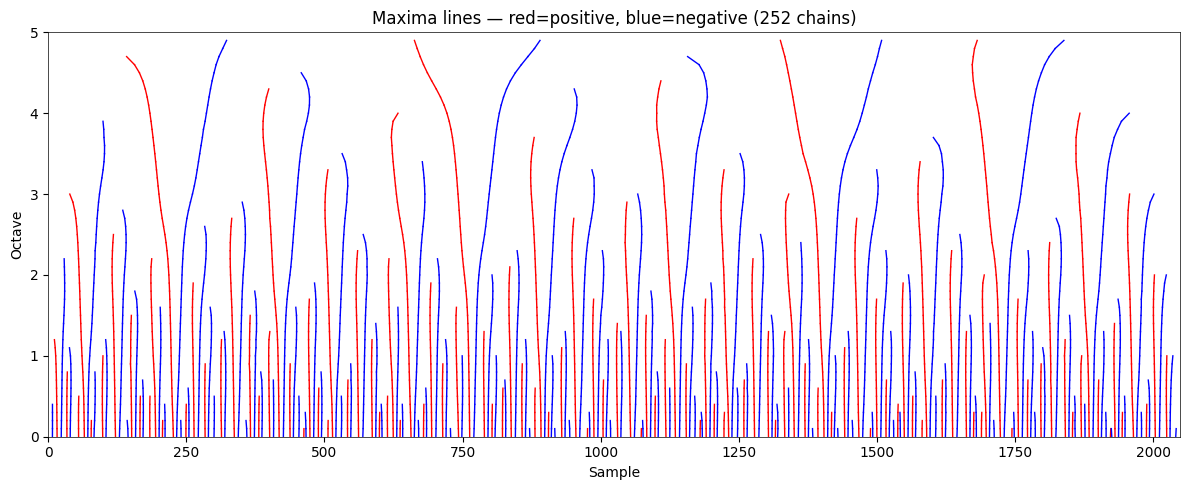

In [ ]:
# [CELL 8]
# Chains colored by sign: positive (red) / negative (blue)
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
for ch in chains:
    sign = np.sign(ch['val'])
    for j in range(len(ch['x']) - 1):
        c = 'red' if sign[j] > 0 else 'blue'
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=c, lw=1, alpha=1)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines — red=positive, blue=negative ({len(chains)} chains)')
plt.tight_layout(); plt.show()

PF computed: 50 scales done, pf_size=50, n_q=12
Spectra computed via LastWave LineFitSig over [1.0, 4.0]


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_43282/3078619312.py:106: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import brentq


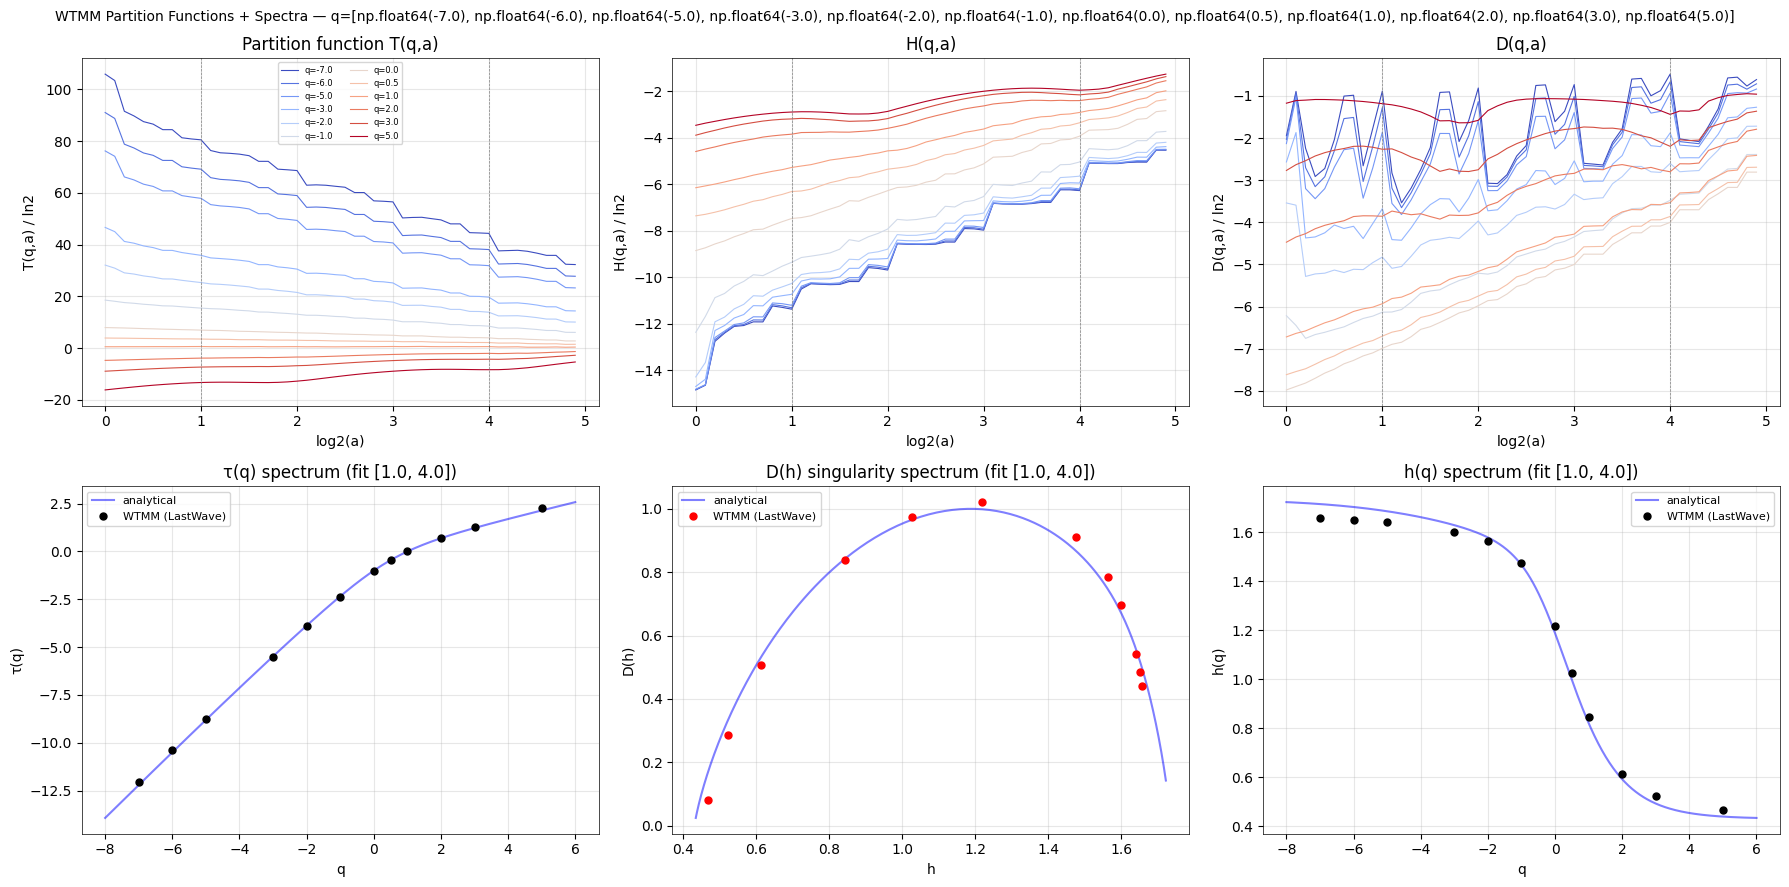


     q     tau(q)       ±σ       h(q)       ±σ       D(q)       ±σ
--------------------------------------------------------------------
  -7.0   -12.0466   0.2719     1.6581   0.0600     0.4395   0.1773
  -6.0   -10.3916   0.2159     1.6512   0.0574     0.4843   0.1563
  -5.0    -8.7454   0.1638     1.6405   0.0532     0.5431   0.1282
  -3.0    -5.4995   0.0786     1.6007   0.0388     0.6975   0.0576
  -2.0    -3.9151   0.0476     1.5648   0.0308     0.7856   0.0289
  -1.0    -2.3863   0.0235     1.4762   0.0239     0.9101   0.0128
   0.0    -1.0212   0.0094     1.2175   0.0127     1.0212   0.0094
   0.5    -0.4597   0.0071     1.0261   0.0095     0.9728   0.0094
   1.0     0.0066   0.0076     0.8444   0.0122     0.8377   0.0114
   2.0     0.7202   0.0239     0.6142   0.0280     0.5082   0.0344
   3.0     1.2812   0.0558     0.5220   0.0356     0.2849   0.0527
   5.0     2.2566   0.1230     0.4674   0.0310     0.0804   0.0360


In [ ]:
# [CELL 9]
# LastWave ground truth — Step 4: Partition functions + tau(q) + D(h) singularity spectrum
#
# DemoWTMM1DDevilStair:
#   qlist = {-7 -6 -5 -3 -2 -1 0 0.5 1 2 3 5}
#   pft = [pf wtmm w.extrep qlist]
#   disp {0w [tauqSpectrum pf 1 4] [singSpectrum pf 1 4]}
#
# tauqSpectrum/singSpectrum do linear regression of T(q,a), H(q,a), D(q,a)
# vs log2(a) over [log2aMin, log2aMax] = [1, 4].
# PF access functions return natural log; convert to log2 by dividing by ln(2).

# ── Declare signatures ──
lib.lw_compute_pf.restype = ctypes.c_int
lib.lw_compute_pf.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.c_int]

lib.lw_get_pf_size.restype = ctypes.c_int
lib.lw_get_pf_size.argtypes = []

lib.lw_get_pf_tq.restype = ctypes.c_int
lib.lw_get_pf_tq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_hq.restype = ctypes.c_int
lib.lw_get_pf_hq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_dq.restype = ctypes.c_int
lib.lw_get_pf_dq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

# ── Compute partition functions ──
q_list = np.array([-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5], dtype=np.float64)
n_q = len(q_list)

n_scales_done = lib.lw_compute_pf(q_list.ctypes.data_as(c_double_p), n_q)
assert n_scales_done > 0, f"lw_compute_pf failed: {lib.lw_get_error()}"

pf_size = lib.lw_get_pf_size()
print(f"PF computed: {n_scales_done} scales done, pf_size={pf_size}, n_q={n_q}")

# ── Extract T(q,a), H(q,a), D(q,a) for all q ──
# Mode: PFEXTENSIVE=0, PFINTENSIVE=1
# PF x-axis: x0 = log2(a_min), dx = 1/n_voice
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
ln2 = np.log(2.0)

tq_all = {}  # q -> T(q,a) array in log2 units
hq_all = {}  # q -> H(q,a)
dq_all = {}  # q -> D(q,a)

for iq, q in enumerate(q_list):
    buf = np.zeros(pf_size, dtype=np.float64)

    ret = lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    tq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_hq(iq, 0, buf.ctypes.data_as(c_double_p))
    hq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_dq(iq, 0, buf.ctypes.data_as(c_double_p))
    dq_all[q] = buf.copy() / ln2 if ret > 0 else None

# ── Spectra via LastWave's own LineFitSig (replicates singSpectrum/tauqSpectrum) ──
log2a_min_fit, log2a_max_fit = 1.0, 4.0

lib.lw_compute_tauq_spectrum.restype = ctypes.c_int
lib.lw_compute_tauq_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]
lib.lw_compute_sing_spectrum.restype = ctypes.c_int
lib.lw_compute_sing_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]

tau_q = np.zeros(n_q, dtype=np.float64)
tau_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_tauq_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    tau_q.ctypes.data_as(c_double_p), tau_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_tauq_spectrum failed: {lib.lw_get_error()}"

h_q = np.zeros(n_q, dtype=np.float64)
h_sigma = np.zeros(n_q, dtype=np.float64)
d_q = np.zeros(n_q, dtype=np.float64)
d_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_sing_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    h_q.ctypes.data_as(c_double_p), h_sigma.ctypes.data_as(c_double_p),
    d_q.ctypes.data_as(c_double_p), d_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_sing_spectrum failed: {lib.lw_get_error()}"

print(f"Spectra computed via LastWave LineFitSig over [{log2a_min_fit}, {log2a_max_fit}]")


# ── Analytical tau(q) and D(h) for the inhomogeneous Cantor measure ──
# For a multinomial measure with parts (r_i, p_i), tau(q) satisfies:
#   sum_i  p_i^q * r_i^(-tau) = 1
# Solved numerically for each q. Then h(q) = tau'(q) and D(h) = q*h - tau.
from scipy.optimize import brentq

r_cantor = np.array([0.3, 0.2, 0.5])
p_cantor = np.array([0.2, 0.5, 0.3])

def tau_equation(tau, q, r, p):
    """sum_i p_i^q * r_i^(-tau) - 1 = 0"""
    return np.sum(p**q * r**(-tau)) - 1.0

q_fine = np.linspace(-8, 6, 500)
tau_analytical = np.zeros_like(q_fine)
for i, q in enumerate(q_fine):
    tau_analytical[i] = brentq(tau_equation, -20, 20, args=(q, r_cantor, p_cantor))

# h(q) = d(tau)/dq via finite differences
h_analytical = np.gradient(tau_analytical, q_fine)
# D(h) = q*h - tau  (Legendre transform)
d_analytical = q_fine * h_analytical - tau_analytical

# ── Plot ──
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel (0,0): T(q,a) vs log2(a) for selected q
colors_q = plt.cm.coolwarm(np.linspace(0, 1, n_q))
for iq, q in enumerate(q_list):
    if tq_all[q] is not None:
        axes[0, 0].plot(log2_a_pf, tq_all[q], '-', color=colors_q[iq], lw=0.8, label=f'q={q}')
axes[0, 0].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].set_xlabel('log2(a)')
axes[0, 0].set_ylabel('T(q,a) / ln2')
axes[0, 0].set_title('Partition function T(q,a)')
axes[0, 0].legend(fontsize=6, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# Panel (0,1): H(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if hq_all[q] is not None:
        axes[0, 1].plot(log2_a_pf, hq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 1].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].set_xlabel('log2(a)')
axes[0, 1].set_ylabel('H(q,a) / ln2')
axes[0, 1].set_title('H(q,a)')
axes[0, 1].grid(True, alpha=0.3)

# Panel (0,2): D(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if dq_all[q] is not None:
        axes[0, 2].plot(log2_a_pf, dq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 2].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].set_xlabel('log2(a)')
axes[0, 2].set_ylabel('D(q,a) / ln2')
axes[0, 2].set_title('D(q,a)')
axes[0, 2].grid(True, alpha=0.3)

# Panel (1,0): tau(q) spectrum
axes[1, 0].plot(q_fine, tau_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 0].plot(q_list, tau_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 0].set_xlabel('q')
axes[1, 0].set_ylabel('\u03c4(q)')
axes[1, 0].set_title(f'\u03c4(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Panel (1,1): D(h) singularity spectrum
axes[1, 1].plot(h_analytical, d_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
sort_idx = np.argsort(h_q)
axes[1, 1].plot(h_q[sort_idx], d_q[sort_idx], 'ro', markersize=5, label='WTMM (LastWave)')
axes[1, 1].set_xlabel('h')
axes[1, 1].set_ylabel('D(h)')
axes[1, 1].set_title(f'D(h) singularity spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# Panel (1,2): h(q) vs q
h_analytical_q = np.gradient(tau_analytical, q_fine)
axes[1, 2].plot(q_fine, h_analytical_q, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 2].plot(q_list, h_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 2].set_xlabel('q')
axes[1, 2].set_ylabel('h(q)')
axes[1, 2].set_title(f'h(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"WTMM Partition Functions + Spectra — q={list(q_list)}", fontsize=10)
plt.tight_layout()
plt.show()

# ── Summary ──
print(f"\n{'q':>6} {'tau(q)':>10} {'±σ':>8} {'h(q)':>10} {'±σ':>8} {'D(q)':>10} {'±σ':>8}")
print('-' * 68)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} {tau_q[iq]:10.4f} {tau_sigma[iq]:8.4f} {h_q[iq]:10.4f} {h_sigma[iq]:8.4f} {d_q[iq]:10.4f} {d_sigma[iq]:8.4f}')

# Faithful WTMM Implementation with GPU Acceleration

A Python reimplementation of LastWave's WTMM (Wavelet Transform Modulus Maxima) algorithm
for multifractal analysis. Faithfully matches LastWave's `CWtd()`, `extrema`, `chain`,
`chainmax`, and `pf wtmm` pipeline.

**GPU**: PyTorch MPS on Apple Silicon M2 Max

In [ ]:
# Cell 10: Imports and device setup
#
# Fix duplicate libomp crash (torch + numba both link OpenMP on macOS)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


PyTorch 2.10.0, device: CPU, dtype: float64


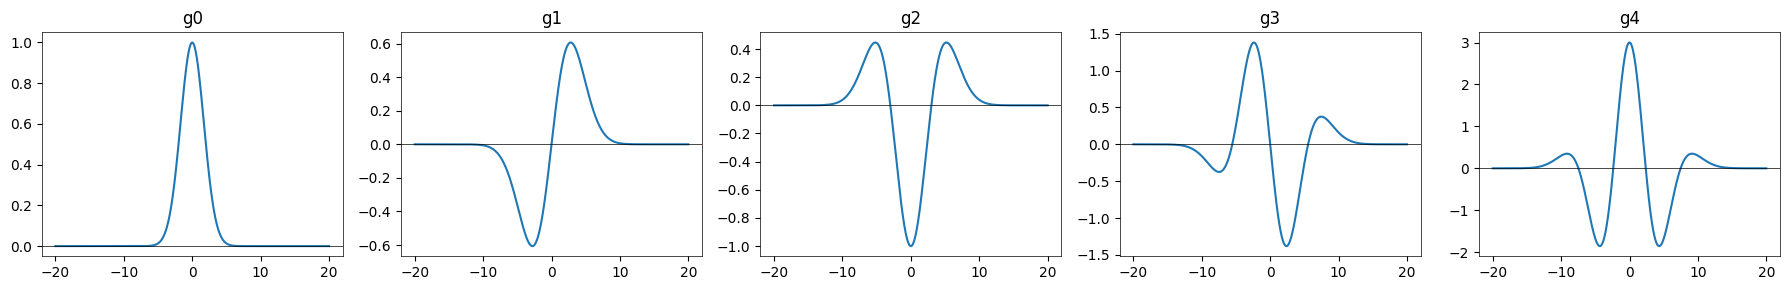

In [ ]:
# Cell 11: Gaussian derivative wavelets — imported from wtmm package

from wtmm.wavelets import WAVELETS, wavelet_direct, wavelet_support

# Quick test: plot g2 at scale a=1
x_test = np.linspace(-20, 20, 1000)
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
for i, name in enumerate(['g0', 'g1', 'g2', 'g3', 'g4']):
    axes[i].plot(x_test, wavelet_direct(x_test, 1.0, name))
    axes[i].set_title(name)
    axes[i].axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12: CWT engine — imported from wtmm package
# FFTW overlap-save matching LastWave's cv_n_real_mp()
# Also includes torch direct convolution fallback

import os
import pyfftw
pyfftw.interfaces.cache.enable()
pyfftw.interfaces.cache.set_keepalive_time(300)

from wtmm.cwt import compute_scales, cwtd_fftw, cwtd

FFTW_THREADS = max(1, os.cpu_count() // 2)
print(f'CWT engines imported. FFTW threads: {FFTW_THREADS}')
print(f'  cwtd_fftw() — overlap-save FFT via pyfftw (matches LastWave cv_n_real_mp)')
print(f'  cwtd()      — direct convolution via torch')

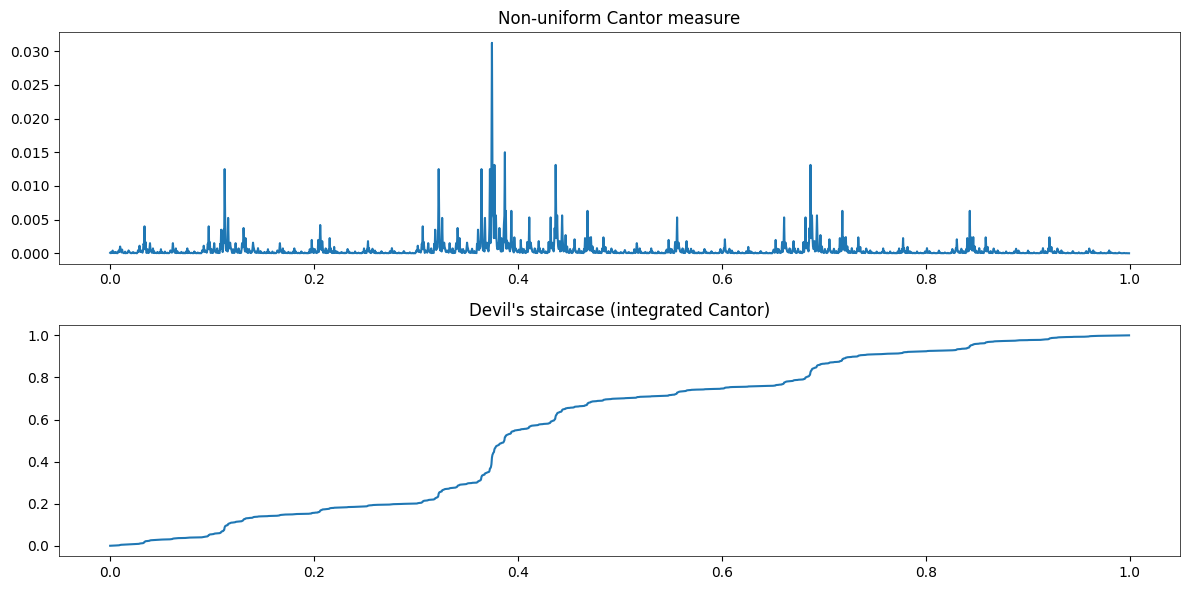

Signal size: 2048, dx: 0.00048828125
Staircase range: [0.0001, 1.0000]


In [ ]:
# Cell 13: Devil's staircase test signal — imported from wtmm package
# Matching LastWave's UCantor() from signal_create.c

from wtmm.signals import ucantor

# Generate devil's staircase: ucantor then prim (cumulative sum)
# DemoWTMM1DDevilStair: ucantor 0w size 0.3 0.2 0.2 0.5 0.5 0.3
# Command parsing: signal size r0 p0 r1 p1 r2 p2
# So r = [0.3, 0.2, 0.5], p = [0.2, 0.5, 0.3]
# nFlip defaults to 0, but C_UCantor does nFlip-- so nFlip = -1 (no flip)

SIZE = 2048
cantor_measure, dx = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)

# prim = cumulative sum (matching LastWave's prim())
devil_staircase = np.cumsum(cantor_measure)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
for spine in ax1.spines.values(): spine.set_linewidth(0.5)
for spine in ax2.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) * dx
ax1.plot(t_axis, cantor_measure)
ax1.set_title('Non-uniform Cantor measure')
ax2.plot(t_axis, devil_staircase)
ax2.set_title("Devil\'s staircase (integrated Cantor)")
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}, dx: {dx}')
print(f'Staircase range: [{devil_staircase.min():.4f}, {devil_staircase.max():.4f}]')

In [ ]:
# Cell 14: CWT + visualization on devil's staircase
# Compare FFTW overlap-save vs LastWave CWT coefficients directly
# DemoWTMM1DDevilStair: cwtd w 1.0 5 10 'g2' -b 'mir'

n_oct_ds, n_voice_ds = 5, 10

t0 = time.time()
coeffs, scales, valid_ranges = cwtd_fftw(devil_staircase, a_min=1.0, n_oct=n_oct_ds,
                                          n_voice=n_voice_ds, wavelet_name='g2', expo=-1.0)
t1 = time.time()
print(f'FFTW CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Compare with LastWave CWT (from cell 2: cwt variable)
max_diffs = np.zeros(len(scales))
rms_diffs = np.zeros(len(scales))
for s in range(len(scales)):
    fp, lp = valid_ranges[s]
    diff = np.abs(coeffs[s, fp:lp+1] - cwt[s, fp:lp+1])
    max_diffs[s] = diff.max()
    rms_diffs[s] = np.sqrt(np.mean(diff**2))

print(f'\nCWT comparison (FFTW overlap-save vs LastWave) over valid ranges:')
print(f'  Max |diff| across all scales: {max_diffs.max():.2e} at scale {scales[np.argmax(max_diffs)]:.2f}')
print(f'  Max RMS diff: {rms_diffs.max():.2e}')
print(f'  Scales with max|diff| > 1e-10: {np.sum(max_diffs > 1e-10)}')

# Detailed per-octave comparison
print(f'\n{"Scale":>8} {"max|diff|":>12} {"RMS diff":>12} {"max|coeff|":>12} {"rel err":>12}')
for s in range(0, len(scales), n_voice_ds):
    fp, lp = valid_ranges[s]
    mc = np.abs(coeffs[s, fp:lp+1]).max()
    rel = max_diffs[s] / mc if mc > 0 else 0
    print(f'{scales[s]:8.2f} {max_diffs[s]:12.2e} {rms_diffs[s]:12.2e} {mc:12.2e} {rel:12.2e}')

# Also compare FFTW vs torch direct convolution
t2 = time.time()
coeffs_torch, scales_torch, vr_torch = cwtd(devil_staircase, a_min=1.0, n_oct=n_oct_ds,
                                              n_voice=n_voice_ds, wavelet_name='g2', expo=-1.0)
t3 = time.time()
print(f'\nTorch direct CWT computed in {t3-t2:.3f}s')

max_diffs_ft = np.zeros(len(scales))
for s in range(len(scales)):
    fp, lp = valid_ranges[s]
    max_diffs_ft[s] = np.abs(coeffs[s, fp:lp+1] - coeffs_torch[s, fp:lp+1]).max()
print(f'Max |FFTW - torch| across all scales: {max_diffs_ft.max():.2e}')

# Plot scalogram
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax, norm_mode='lglobal')
ax.set_title('|CWT| lglobal (FFTW overlap-save, g2 wavelet)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()


# Torch vs LastWave comparison
max_diffs_torch_lw = np.zeros(len(scales))
rms_diffs_torch_lw = np.zeros(len(scales))
for s in range(len(scales)):
    fp, lp = valid_ranges[s]
    diff = np.abs(coeffs_torch[s, fp:lp+1] - cwt[s, fp:lp+1])
    max_diffs_torch_lw[s] = diff.max()
    rms_diffs_torch_lw[s] = np.sqrt(np.mean(diff**2))

print(f'\nCWT comparison (Torch direct vs LastWave) over valid ranges:')
print(f'  Max |diff| across all scales: {max_diffs_torch_lw.max():.2e} at scale {scales[np.argmax(max_diffs_torch_lw)]:.2f}')
print(f'  Max RMS diff: {rms_diffs_torch_lw.max():.2e}')
print(f'  Scales with max|diff| > 1e-10: {np.sum(max_diffs_torch_lw > 1e-10)}')

print(f'\n{"Scale":>8} {"FFTW-LW":>12} {"Torch-LW":>12} {"FFTW-Torch":>12}')
for s in range(0, len(scales), n_voice_ds):
    fp, lp = valid_ranges[s]
    print(f'{scales[s]:8.2f} {max_diffs[s]:12.2e} {max_diffs_torch_lw[s]:12.2e} {max_diffs_ft[s]:12.2e}')


In [ ]:
# Cell 15: Extrema detection — imported from wtmm package
# Faithful to ext_compute.c

from wtmm.extrema import compute_extlis_numba, compute_extrep

dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=5, n_voice=10, a_min=1.0,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
for sidx in [0, 10, 20, 30, 40, 49]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

Numba warmup: 0.228s
Total extrema: 3644
Extrema computed in 0.001s
  Scale 0 (a=1.00): 252 extrema
  Scale 10 (a=2.00): 127 extrema
  Scale 20 (a=4.00): 63 extrema
  Scale 30 (a=8.00): 32 extrema
  Scale 40 (a=16.00): 16 extrema
  Scale 49 (a=29.86): 7 extrema


In [ ]:
# Cell 16: Chaining — imported from wtmm package
# Faithful to ext_chain.c

from wtmm.chains import (
    chain_all,
    save_chain_state,
    chain_delete_all,
    chain_max_wrapper,
    trace_chains,
)

t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=5, n_voice=10)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, 5 * 10)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=5, n_voice=10)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=5, n_voice=10, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

Chaining: 0.002s
Delete: 0.003s, deleted 0 chains
ChainMax: 0.196s
Total chaining: 0.201s
Remaining extrema: 3644


Pre-deletion chains: 237
Surviving chains: 237
Deleted chains: 0


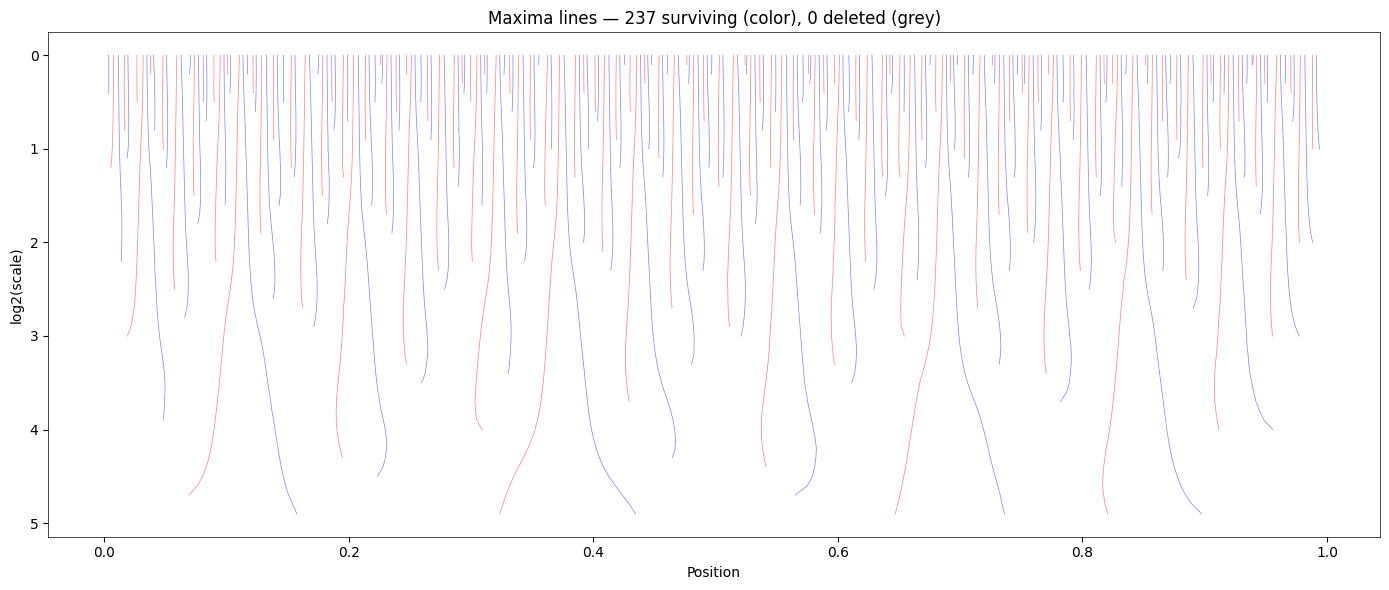

In [ ]:
# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, 5 * 10)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, *_rest in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, *_rest in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Draw deleted chains first (background, grey)
for pos, sv, sign, *_rest in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Draw surviving chains on top
for pos, sv, sign, *_rest in post_del_chains:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — {len(post_del_chains)} surviving (color), {len(deleted_chains)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Partition function computed in 0.004s, up to scale index 49
Extrema per scale (sample): [252 237 225 208 191]...[10  9  9  7  7]


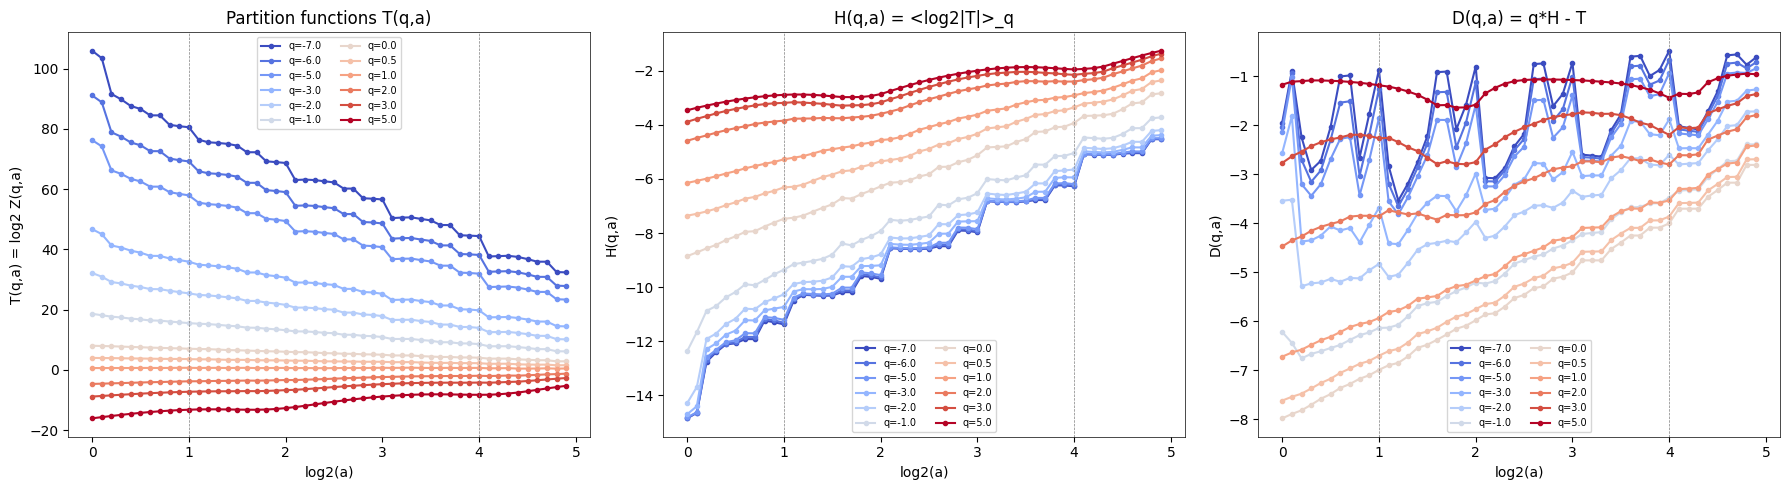

Gray dashed lines show regression range [log2(a)=1 to 4]


In [ ]:
# Cell 18: Partition function — imported from wtmm package
# Faithful to pf_lib.c PFComputeOneScaleFLOAT

from wtmm.partition import (
    compute_partition_function,
    pf_get_T,
    pf_get_H,
    pf_get_D,
)

q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=5, n_voice=10, a_min=1.0, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a) — this is what LastWave's "pf get t" returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')

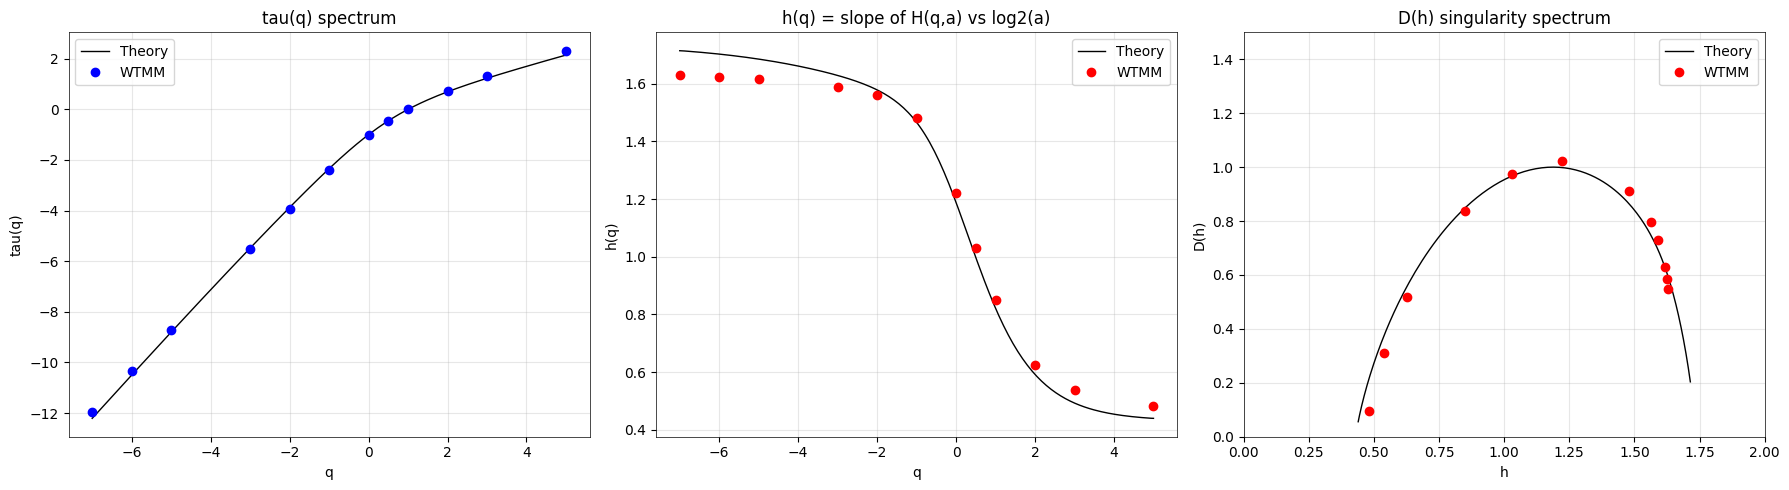


Theoretical: expo=-1.0, so tau_WTMM = tau_measure (integration + 1/a cancel)
h range: [0.458, 1.709]

q	 tau_WTMM	 tau_theory	 diff		 h_WTMM		 h_theory
 -7.0	 -11.9521	 -12.2063	 +0.2541	   1.6291	   1.7094
 -6.0	 -10.3257	 -10.4969	 +0.1712	   1.6235	   1.7021
 -5.0	  -8.7059	  -8.8021	 +0.0962	   1.6156	   1.6832
 -3.0	  -5.4983	  -5.4818	 -0.0165	   1.5890	   1.6242
 -2.0	  -3.9210	  -3.8756	 -0.0453	   1.5622	   1.5690
 -1.0	  -2.3912	  -2.3439	 -0.0473	   1.4797	   1.4378
  0.0	  -1.0216	  -1.0000	 -0.0216	   1.2225	   1.1768
  0.5	  -0.4576	  -0.4534	 -0.0042	   1.0311	   1.0000
  1.0	   0.0111	  -0.0000	 +0.0111	   0.8492	   0.8354
  2.0	   0.7321	   0.6928	 +0.0393	   0.6255	   0.6139
  3.0	   1.3078	   1.2277	 +0.0801	   0.5389	   0.5093
  5.0	   2.3158	   2.1440	 +0.1718	   0.4820	   0.4581


In [ ]:
# Cell 19: tau(q), h(q), D(h) spectrum — imported from wtmm package

from wtmm.spectra import compute_spectra, theoretical_devil_staircase

spectra = compute_spectra(pf, log2_a_min=1.0, log2_a_max=4.0)

# Theoretical values — use expo=-1 to match our CWT normalization
q_fine = np.linspace(-7, 5, 200)
tau_theory, h_theory, D_theory = theoretical_devil_staircase(
    q_fine, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

tau_theory_q, h_theory_q, D_theory_q = theoretical_devil_staircase(
    spectra['q_list'], r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# 1. tau(q)
ax = axes[0]
ax.plot(q_fine, tau_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q) comparison
ax = axes[1]
ax.plot(q_fine, h_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) = slope of H(q,a) vs log2(a)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. D(h) singularity spectrum
ax = axes[2]
ax.plot(h_theory, D_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

# Print comparison
print(f'\nTheoretical: expo={-1.0}, so tau_WTMM = tau_measure (integration + 1/a cancel)')
print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
print('\nq\t tau_WTMM\t tau_theory\t diff\t\t h_WTMM\t\t h_theory')
for i, q in enumerate(spectra['q_list']):
    print(f'{q:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
          f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_43282/2992841337.py:81: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()
/Users/amasaryk/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


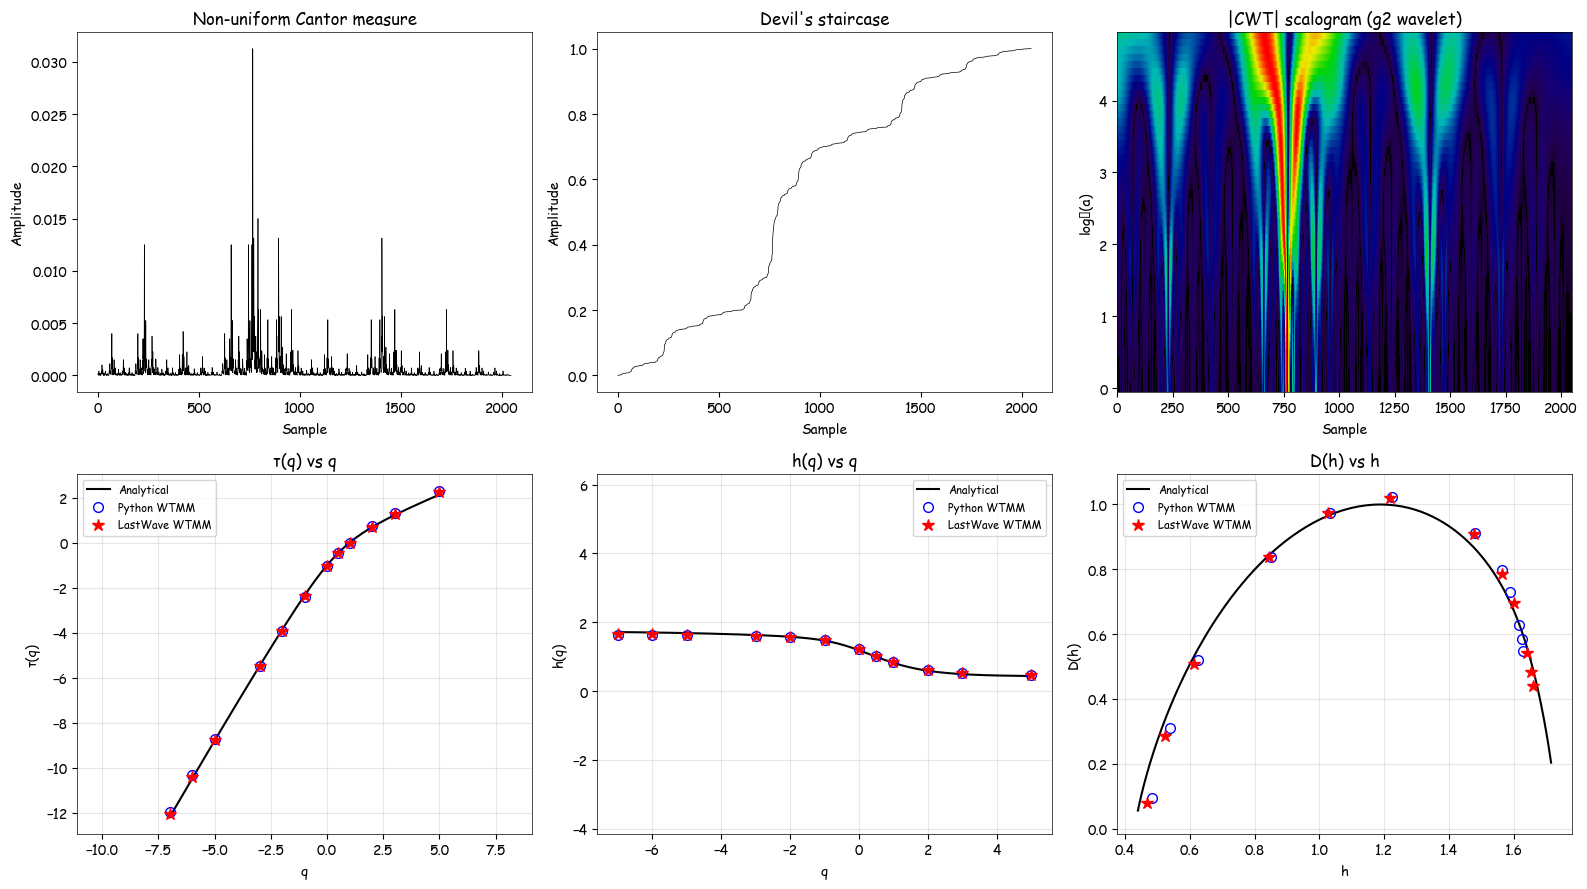

In [ ]:
# CELL 20
# Three-way comparison: LastWave WTMM vs Python WTMM vs Analytical
#
# Top row: signals and scalogram
# Bottom row: tau(q), h(q), D(h) spectra with equal aspect

import matplotlib as mpl

# Comic Sans styling
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Thin spines on all axes
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# ── Top row: signals + scalogram ──

# (0,0): Cantor measure
ax = axes[0, 0]
ax.plot(cantor_measure, 'k-', lw=0.5)
ax.set_title('Non-uniform Cantor measure')
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')

# (0,1): Devil's staircase
ax = axes[0, 1]
ax.plot(devil_staircase, 'k-', lw=0.5)
ax.set_title("Devil's staircase")
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')

# (0,2): Scalogram
ax = axes[0, 2]
scalogram_lastwave(coeffs, scales=scales, ax=ax, norm_mode='lglobal')
ax.set_title('|CWT| scalogram (g2 wavelet)')

# ── Bottom row: three-way spectra (equal aspect) ──

# (1,0): tau(q) vs q
ax = axes[1, 0]
ax.plot(q_fine, tau_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# (1,1): h(q) vs q
ax = axes[1, 1]
ax.plot(q_fine, h_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(q_list, h_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# (1,2): D(h) vs h
ax = axes[1, 2]
ax.plot(h_theory, D_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['h_q'], spectra['D_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(h_q, d_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

# Reset font
mpl.rcParams['font.family'] = 'sans-serif'

Total extrema: LW=3645, Python=3644
Count mismatches at scales: [1]
  Scale 1: LW=238, Py=237

    q      max|dT|      max|dH|      max|dD|   worst scale
------------------------------------------------------------
 -7.0     0.009547     0.001126     0.017431     10 (log2a=1.0)
 -6.0     0.010416     0.000626     0.013611     10 (log2a=1.0)
 -5.0     0.010429     0.001220     0.007424     10 (log2a=1.0)
 -3.0     0.011941     0.014004     0.053952      1 (log2a=0.1)
 -2.0     0.031736     0.021468     0.074673      1 (log2a=0.1)
 -1.0     0.033902     0.024209     0.009693      1 (log2a=0.1)
  0.0     0.006075     0.016772     0.006075      1 (log2a=0.1)
  0.5     0.001185     0.004455     0.003413      1 (log2a=0.1)
  1.0     0.000145     0.000670     0.000814      1 (log2a=0.1)
  2.0     0.000008     0.000014     0.000036     40 (log2a=4.0)
  3.0     0.000001     0.000002     0.000007     40 (log2a=4.0)
  5.0     0.000001     0.000000     0.000000     44 (log2a=4.4)


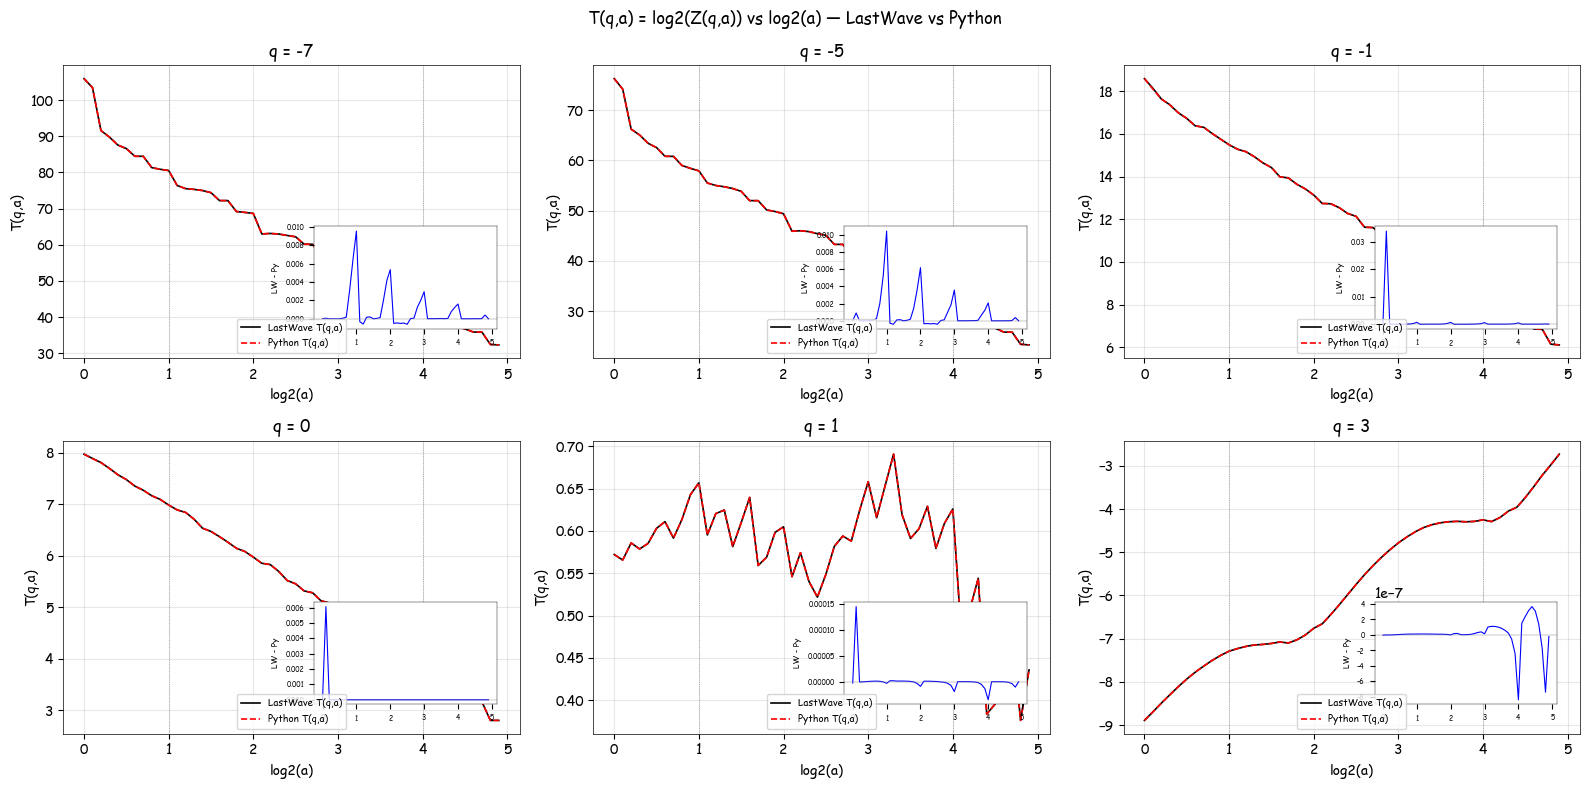

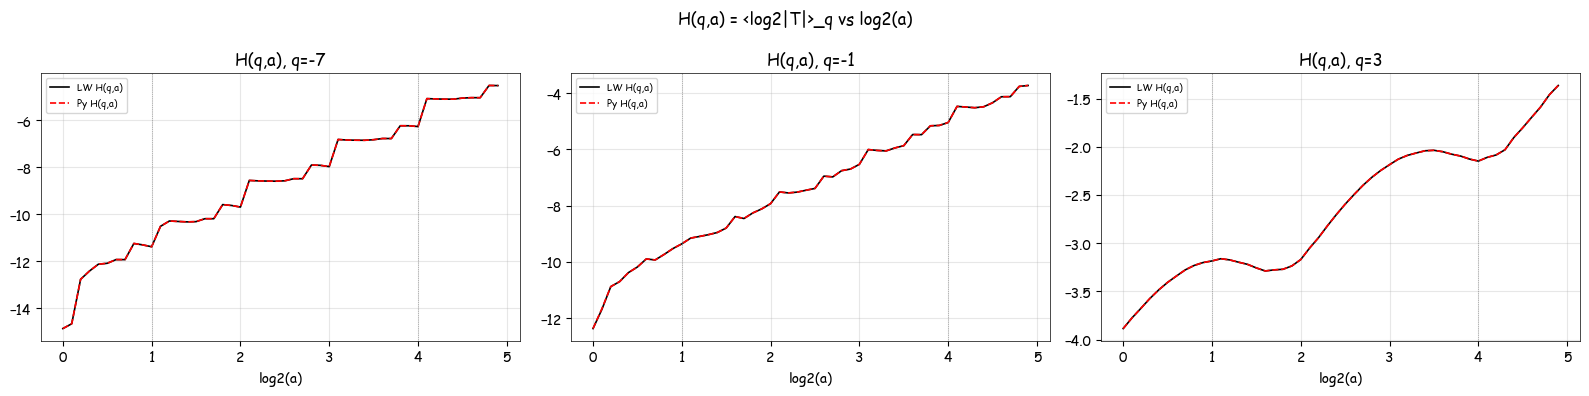

In [ ]:
# CELL 21
# Extrema + Partition function comparison: LastWave vs Python
#
# 1. Extrema counts and ordinate values at each scale
# 2. T(q,a), H(q,a), D(q,a) at every scale for all q values
# 3. Plots of T(q,a) vs log2(a) for selected q values

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ═══ Part 1: Extrema comparison ═══
lw_ext_post = {}
lw_counts = np.zeros(n_scales, dtype=int)
py_counts = np.zeros(n_scales, dtype=int)

for o in range(1, n_oct + 1):
    for v in range(n_voice):
        scale_idx = (o - 1) * n_voice + v
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v,
                pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p),
                count)
            lw_ext_post[scale_idx] = (pos[:got], val[:got])
            lw_counts[scale_idx] = got
        else:
            lw_ext_post[scale_idx] = (np.array([]), np.array([]))
        py_counts[scale_idx] = len(extrep_ord[scale_idx])

print(f'Total extrema: LW={lw_counts.sum()}, Python={py_counts.sum()}')
mismatches = np.where(lw_counts != py_counts)[0]
if len(mismatches):
    print(f'Count mismatches at scales: {mismatches}')
    for s in mismatches:
        print(f'  Scale {s}: LW={lw_counts[s]}, Py={py_counts[s]}')

# ═══ Part 2: T(q,a), H(q,a), D(q,a) comparison ═══
ln2 = np.log(2.0)

# Extract all LW partition function curves
lw_T = {}  # q_idx -> array over scales
lw_H = {}
lw_D = {}
for iq in range(len(q_list)):
    buf = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    lw_T[iq] = buf.copy() / ln2

    buf2 = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_hq(iq, 0, buf2.ctypes.data_as(c_double_p))
    lw_H[iq] = buf2.copy() / ln2

    buf3 = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_dq(iq, 0, buf3.ctypes.data_as(c_double_p))
    lw_D[iq] = buf3.copy() / ln2

# Python partition function curves
py_T = {}
py_H = {}
py_D = {}
for iq in range(len(q_list)):
    py_T[iq] = pf_get_T(pf, iq, 'extensive')
    py_H[iq] = pf_get_H(pf, iq, 'extensive')
    py_D[iq] = pf_get_D(pf, iq, q_list[iq], 'extensive')

# ═══ Part 3: Summary table — max |diff| for each q ═══
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
n_compare = min(pf_size, n_scales)

print(f'\n{"q":>5} {"max|dT|":>12} {"max|dH|":>12} {"max|dD|":>12}  {"worst scale":>12}')
print('-' * 60)
for iq, q in enumerate(q_list):
    dT = np.abs(lw_T[iq][:n_compare] - py_T[iq][:n_compare])
    dH = np.abs(lw_H[iq][:n_compare] - py_H[iq][:n_compare])
    dD = np.abs(lw_D[iq][:n_compare] - py_D[iq][:n_compare])
    # ignore NaN
    dT = np.where(np.isfinite(dT), dT, 0)
    dH = np.where(np.isfinite(dH), dH, 0)
    dD = np.where(np.isfinite(dD), dD, 0)
    worst = np.argmax(dT)
    print(f'{q:5.1f} {dT.max():12.6f} {dH.max():12.6f} {dD.max():12.6f}  {worst:5d} (log2a={log2_a_pf[worst]:.1f})')

# ═══ Part 4: Plots — T(q,a) vs log2(a) for selected q values ═══
sel_q = [-7, -5, -1, 0, 1, 3]
sel_iq = [list(q_list).index(q) for q in sel_q]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

for idx, (ax, iq) in enumerate(zip(axes.flatten(), sel_iq)):
    q = q_list[iq]
    x = log2_a_pf[:n_compare]
    ax.plot(x, lw_T[iq][:n_compare], 'k-', lw=1.2, label='LastWave T(q,a)')
    ax.plot(x, py_T[iq][:n_compare], 'r--', lw=1.2, label='Python T(q,a)')

    # Show fit range
    ax.axvline(1.0, color='gray', ls=':', lw=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.5)

    ax.set_xlabel('log2(a)')
    ax.set_ylabel('T(q,a)')
    ax.set_title(f'q = {q}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # Inset: difference
    inset = ax.inset_axes([0.55, 0.1, 0.4, 0.35])
    diff = lw_T[iq][:n_compare] - py_T[iq][:n_compare]
    inset.plot(x, diff, 'b-', lw=0.8)
    inset.set_ylabel('LW - Py', fontsize=6)
    inset.tick_params(labelsize=5)
    inset.axhline(0, color='gray', ls='-', lw=0.3)
    for sp in inset.spines.values(): sp.set_linewidth(0.3)

plt.suptitle('T(q,a) = log2(Z(q,a)) vs log2(a) — LastWave vs Python', fontsize=12)
plt.tight_layout()
plt.show()

# ═══ Part 5: H(q,a) comparison for extreme q ═══
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for ax in axes2: 
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

for ax, iq in zip(axes2, [0, 5, 10]):  # q=-7, q=-1, q=3
    q = q_list[iq]
    x = log2_a_pf[:n_compare]
    ax.plot(x, lw_H[iq][:n_compare], 'k-', lw=1.2, label='LW H(q,a)')
    ax.plot(x, py_H[iq][:n_compare], 'r--', lw=1.2, label='Py H(q,a)')
    ax.axvline(1.0, color='gray', ls=':', lw=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.5)
    ax.set_title(f'H(q,a), q={q}')
    ax.set_xlabel('log2(a)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('H(q,a) = <log2|T|>_q vs log2(a)', fontsize=12)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


Loaded 639564 samples from cfwb (raw)
Time range: 1993.9358 to 2007.8540 (decimal year)
dt = 0.000019 year (10.0 min)
Value range: -32768.000 to 32714.000 counts
Start filter: 2003.081 -> 2003.2218 decimal year
After date filter: 224406 samples
Using segment of 5760 samples starting at index 33120
Segment time: 2004.0479 to 2004.1574
Segment value range: 2553.000 to 2916.000 counts


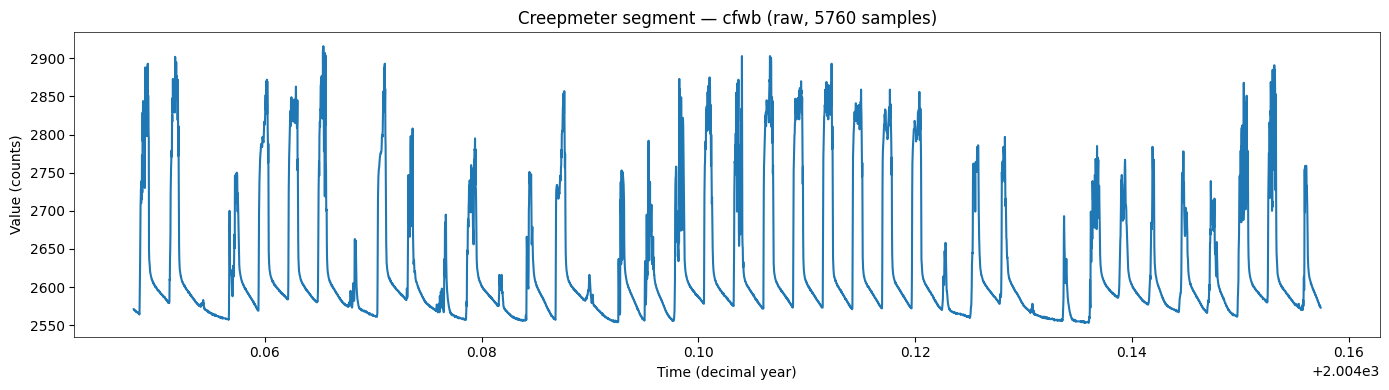

In [141]:
# CELL 22
# Load creepmeter data — configurable station and source
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.

import os
import gzip

# ══════════════════════════════════════════════════════════════
# CONFIGURE HERE
# ══════════════════════════════════════════════════════════════
# Option A: cleaned data (displacement in mm, gap-filled)
#   station = 'xmr1'
#   source = 'cleaned'
#
# Option B: raw data (counts, may need calibration)
#   station = 'cfwd'
#   source = 'raw'
#
station = 'cfwb'
source = 'raw'       # 'cleaned' or 'raw'
raw_era = 'new'      # 'new' or 'old' (only used when source='raw')
seg_len = 1440*4      # segment length (power of 2 recommended)
start_date = 2003.081    # e.g. 1997.200 = year 1997, day 200. None = auto
end_date = None      # e.g. 2005.365. None = auto
# ══════════════════════════════════════════════════════════════

base_dir = '/Users/amasaryk/projects/Creep'

if source == 'cleaned':
    # Try gz first, then plain
    candidates = [
        f'{base_dir}/Cleaned_data_creep/gz/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min.gz',
        f'{base_dir}/Cleaned_data_creep/{station}.10min',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        raise FileNotFoundError(f'No cleaned file found for station {station}. '
                                f'Tried: {candidates}')
    opener = gzip.open if fpath.endswith('.gz') else open
    with opener(fpath, 'rt') as f:
        lines = f.readlines()
    unit = 'mm'
    bad_val = -9999

elif source == 'raw':
    # raw/new and raw/old
    candidates = [
        f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/{station}',
    ]
    fpath = None
    for c in candidates:
        if os.path.exists(c):
            fpath = c
            break
    if fpath is None:
        # List available raw files to help the user
        raw_dir = f'{base_dir}/Creepmeters_Raw/Creep/raw/{raw_era}/'
        if os.path.isdir(raw_dir):
            avail = sorted(os.listdir(raw_dir))
            print(f'Available raw files: {avail}')
        raise FileNotFoundError(f'No raw file found for station {station}. '
                                f'Tried: {candidates}')
    with open(fpath, 'r') as f:
        lines = f.readlines()
    unit = 'counts'
    bad_val = -9999
else:
    raise ValueError(f"source must be 'cleaned' or 'raw', got '{source}'")

# Parse: year  day_of_year  value
data = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 3:
        try:
            year = float(parts[0])
            doy = float(parts[1])
            val = float(parts[2])
            if val != bad_val:
                t_val = year + doy / 365.25
                data.append((t_val, val))
        except ValueError:
            continue

data = np.array(data)
t_creep = data[:, 0]
x_creep = data[:, 1]
dt_creep = np.median(np.diff(t_creep))

print(f'Loaded {len(x_creep)} samples from {os.path.basename(fpath)} ({source})')
print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
print(f'Value range: {x_creep.min():.3f} to {x_creep.max():.3f} {unit}')

# Apply date range filter if specified
if start_date is not None or end_date is not None:
    # Convert year.doy to decimal year
    def doy_to_decimal(ydoy):
        yr = int(ydoy)
        doy = (ydoy - yr) * 1000  # e.g. 1997.200 -> year=1997, doy=200
        return yr + doy / 365.25
    
    mask = np.ones(len(t_creep), dtype=bool)
    if start_date is not None:
        t_start = doy_to_decimal(start_date)
        mask &= t_creep >= t_start
        print(f'Start filter: {start_date} -> {t_start:.4f} decimal year')
    if end_date is not None:
        t_end = doy_to_decimal(end_date)
        mask &= t_creep <= t_end
        print(f'End filter: {end_date} -> {t_end:.4f} decimal year')
    
    t_creep = t_creep[mask]
    x_creep = x_creep[mask]
    print(f'After date filter: {len(x_creep)} samples')

# Find a clean segment (no gaps)
seg_len = min(seg_len, len(x_creep))
found_clean = False
for start in range(0, len(x_creep) - seg_len, seg_len // 4):
    segment_c = x_creep[start:start + seg_len]
    t_seg_c = t_creep[start:start + seg_len]
    gaps = np.diff(t_seg_c)
    if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
        found_clean = True
        break

if not found_clean:
    # Fall back to first seg_len contiguous samples
    start = 0
    segment_c = x_creep[:seg_len]
    t_seg_c = t_creep[:seg_len]
    print(f'WARNING: no perfectly clean segment found, using first {seg_len} samples')

segment_c = segment_c.copy()
print(f'Using segment of {len(segment_c)} samples starting at index {start}')
print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} {unit}')

fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
ax.plot(t_seg_c, segment_c)
ax.set_xlabel('Time (decimal year)')
ax.set_ylabel(f'Value ({unit})')
ax.set_title(f'Creepmeter segment — {station} ({source}, {len(segment_c)} samples)')
plt.tight_layout()
plt.show()

First-difference stats: median=0.0000, MAD=1.0000, threshold=100.0000
Detected 28 spikes


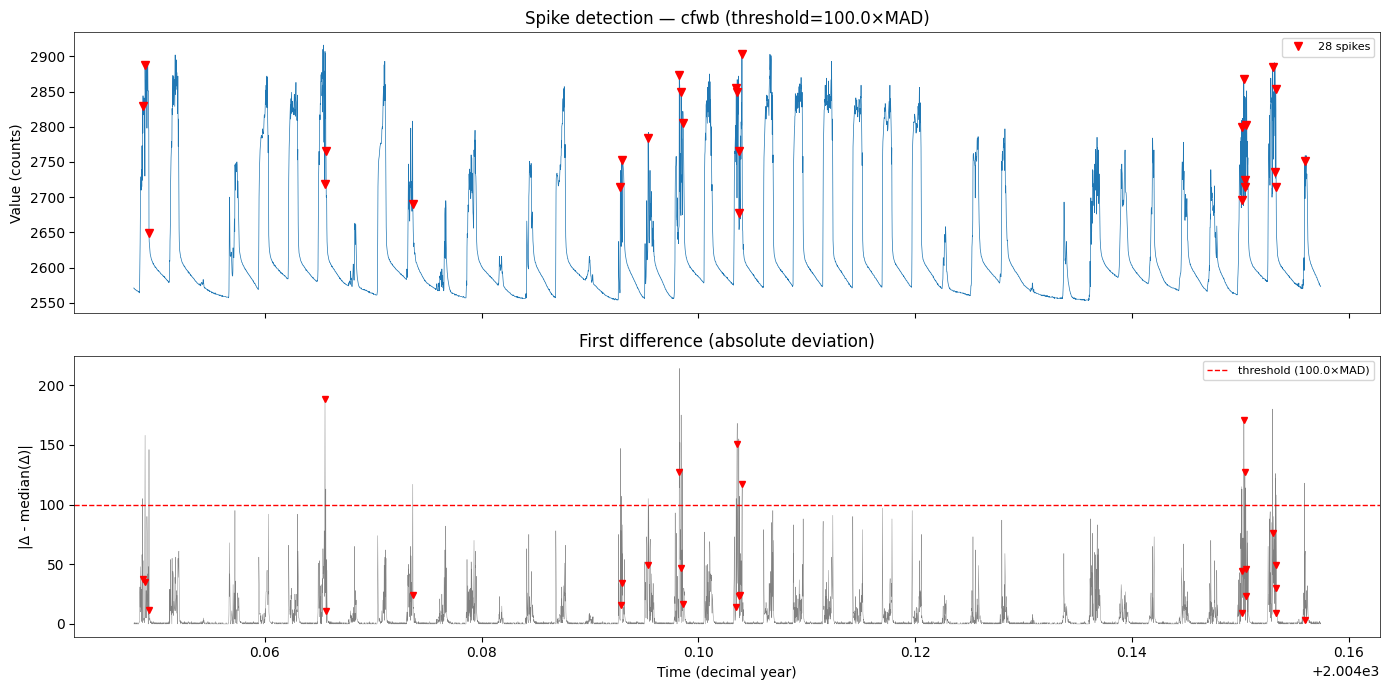

Removed 28 spikes — segment_c updated


In [140]:
# Cell 22b: Spike detector — find and optionally remove telemetry glitches
#
# Detects spikes using a median-absolute-deviation (MAD) filter on
# the first difference of the signal. Telemetry glitches typically
# appear as single-sample jumps that immediately reverse.
#
# Set remove_spikes = True to replace detected spikes with interpolated values.
# The cleaned signal overwrites segment_c so downstream cells use it automatically.

# ══════════════════════════════════════════════════════════════
# CONFIGURE HERE
# ══════════════════════════════════════════════════════════════
mad_threshold = 100.0   # MAD multiplier — higher = fewer detections
min_spike_gap = 1      # minimum samples between independent spikes
remove_spikes = True   # True = replace spikes with linear interpolation
# ══════════════════════════════════════════════════════════════

diff = np.diff(segment_c)

# MAD of first difference (robust scale estimate)
med_diff = np.median(diff)
mad = np.median(np.abs(diff - med_diff))
if mad == 0:
    # Fallback for quantized data: use IQR-based scale
    q75, q25 = np.percentile(np.abs(diff - med_diff), [75, 25])
    mad = (q75 - q25) / 1.349  # IQR to std conversion
    if mad == 0:
        mad = np.std(diff)
    print(f'MAD was 0 (quantized data), using fallback scale: {mad:.4f}')

threshold = mad_threshold * mad
print(f'First-difference stats: median={med_diff:.4f}, MAD={mad:.4f}, '
      f'threshold={threshold:.4f}')

# Detect spikes: large jump followed by reversal within a few samples
spike_indices = []
abs_diff = np.abs(diff - med_diff)
candidates = np.where(abs_diff > threshold)[0]

i = 0
while i < len(candidates):
    idx = candidates[i]
    # Check for reversal: a spike at idx means diff[idx] is large,
    # and diff[idx+1] (or nearby) should be large in opposite direction
    is_spike = False
    for offset in range(1, min_spike_gap + 1):
        if idx + offset < len(diff):
            if abs_diff[idx + offset] > threshold:
                # Opposite sign = reversal
                if diff[idx] * diff[idx + offset] < 0:
                    is_spike = True
                    break
    if is_spike:
        # The spike is at sample idx+1 (the point between the two jumps)
        spike_indices.append(idx + 1)
    else:
        # Single large jump without reversal — could be a step/event, flag but don't remove
        spike_indices.append(idx + 1)  # still flag it
    # Skip ahead past this spike cluster
    i += 1
    while i < len(candidates) and candidates[i] - candidates[i-1] <= min_spike_gap:
        i += 1

spike_indices = np.array(spike_indices)
print(f'Detected {len(spike_indices)} spikes')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax in axes:
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(t_seg_c, segment_c, linewidth=0.5)
if len(spike_indices) > 0:
    ax.plot(t_seg_c[spike_indices], segment_c[spike_indices], 'rv', markersize=6,
            label=f'{len(spike_indices)} spikes')
    ax.legend(fontsize=8)
ax.set_ylabel(f'Value ({unit})')
ax.set_title(f'Spike detection — {station} (threshold={mad_threshold}×MAD)')

ax = axes[1]
ax.plot(t_seg_c[1:], abs_diff, linewidth=0.3, color='grey')
ax.axhline(threshold, color='red', ls='--', lw=1, label=f'threshold ({mad_threshold}×MAD)')
if len(spike_indices) > 0:
    valid_di = spike_indices[spike_indices < len(abs_diff)]
    ax.plot(t_seg_c[1:][valid_di], abs_diff[valid_di], 'rv', markersize=4)
ax.set_ylabel('|Δ - median(Δ)|')
ax.set_xlabel('Time (decimal year)')
ax.legend(fontsize=8)
ax.set_title('First difference (absolute deviation)')

plt.tight_layout()
plt.show()

# Remove spikes by linear interpolation
if remove_spikes and len(spike_indices) > 0:
    segment_cleaned = segment_c.copy()
    for si in spike_indices:
        # Find nearest clean neighbors
        lo = si - 1
        while lo >= 0 and lo in spike_indices:
            lo -= 1
        hi = si + 1
        while hi < len(segment_cleaned) and hi in spike_indices:
            hi += 1
        if lo >= 0 and hi < len(segment_cleaned):
            # Linear interpolation
            frac = (si - lo) / (hi - lo)
            segment_cleaned[si] = segment_cleaned[lo] + frac * (segment_cleaned[hi] - segment_cleaned[lo])
        elif lo >= 0:
            segment_cleaned[si] = segment_cleaned[lo]
        elif hi < len(segment_cleaned):
            segment_cleaned[si] = segment_cleaned[hi]
    
    segment_c = segment_cleaned
    print(f'Removed {len(spike_indices)} spikes — segment_c updated')
else:
    if len(spike_indices) == 0:
        print('No spikes detected — segment_c unchanged')
    else:
        print(f'{len(spike_indices)} spikes detected but remove_spikes=False — segment_c unchanged')

CWT computed in 0.239s
Coefficients shape: (50, 5760), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (20, 5739), coarsest: (601, 5158)


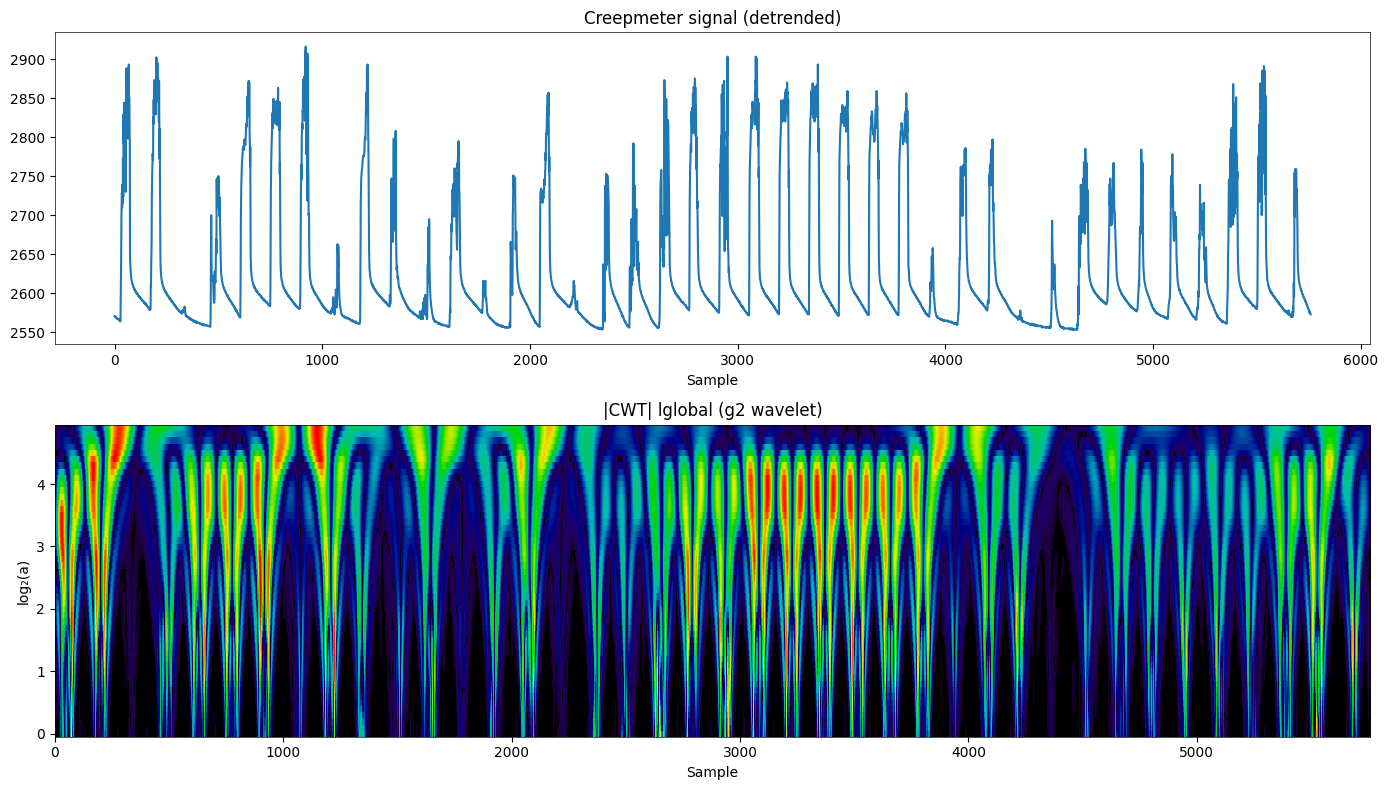

ov_to_log2a() defined — n_voice_c = 10
  Example: 1.1 → log2a=0.00, 2.1 → log2a=1.00, 5.10 → log2a=4.90


In [142]:
# Cell 23: CWT on creepmeter data + scalogram

n_oct_c, n_voice_c = 5, 10

t0 = time.time()
coeffs_c, scales_c, valid_ranges_c = cwtd_fftw(segment_c, a_min=1.0, n_oct=n_oct_c,
                                                    n_voice=n_voice_c, wavelet_name='g3', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs_c.shape}, Scales: {len(scales_c)} ({scales_c[0]:.2f} to {scales_c[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges_c[0]}, coarsest: {valid_ranges_c[-1]}')

# Scalogram — log2 of modulus
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(segment_c)
ax.set_title('Creepmeter signal (detrended)')
ax.set_xlabel('Sample')

ax = axes[1]
im = scalogram_lastwave(coeffs_c, scales=scales_c, ax=ax,
                        norm_mode='lglobal')
ax.set_xlabel('Sample')
ax.set_title('|CWT| lglobal (g2 wavelet)')
#plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')

plt.tight_layout()
plt.show()

# ── octave.voice notation helper ──
# Format: octave.voice where octave starts at 1, voice starts at 1
# Example with n_voice=10: 1.1 = finest scale (log2a=0), 2.1 = log2a=1.0, 3.6 = log2a=2.5
# Conversion: log2_a = (octave - 1) + (voice - 1) / n_voice_c

def ov_to_log2a(ov, n_voice=None):
    """Convert octave.voice notation to log2(a).
    E.g. 2.1 with n_voice=10 → log2a = 1.0, 3.6 → log2a = 2.5"""
    if n_voice is None:
        n_voice = n_voice_c
    octave = int(ov)
    voice = round((ov - octave) * 10)
    if voice < 1 or voice > n_voice:
        print(f'WARNING: voice {voice} out of range [1, {n_voice}]')
    return (octave - 1) + (voice - 1) / n_voice

def log2a_to_ov(log2a, n_voice=None):
    """Convert log2(a) back to octave.voice notation for display."""
    if n_voice is None:
        n_voice = n_voice_c
    octave = int(log2a) + 1
    voice = round((log2a - int(log2a)) * n_voice) + 1
    if voice > n_voice:
        octave += 1
        voice = 1
    return octave + voice / 10

print(f'ov_to_log2a() defined — n_voice_c = {n_voice_c}')
print(f'  Example: 1.1 → log2a={ov_to_log2a(1.1):.2f}, '
      f'2.1 → log2a={ov_to_log2a(2.1):.2f}, '
      f'{n_oct_c}.{n_voice_c} → log2a={ov_to_log2a(n_oct_c + n_voice_c/10):.2f}')


Hurst exponent of raw signal (R/S): H = 0.8686 ± 0.0274
H per voice: min=0.798, max=0.933, mean=0.844


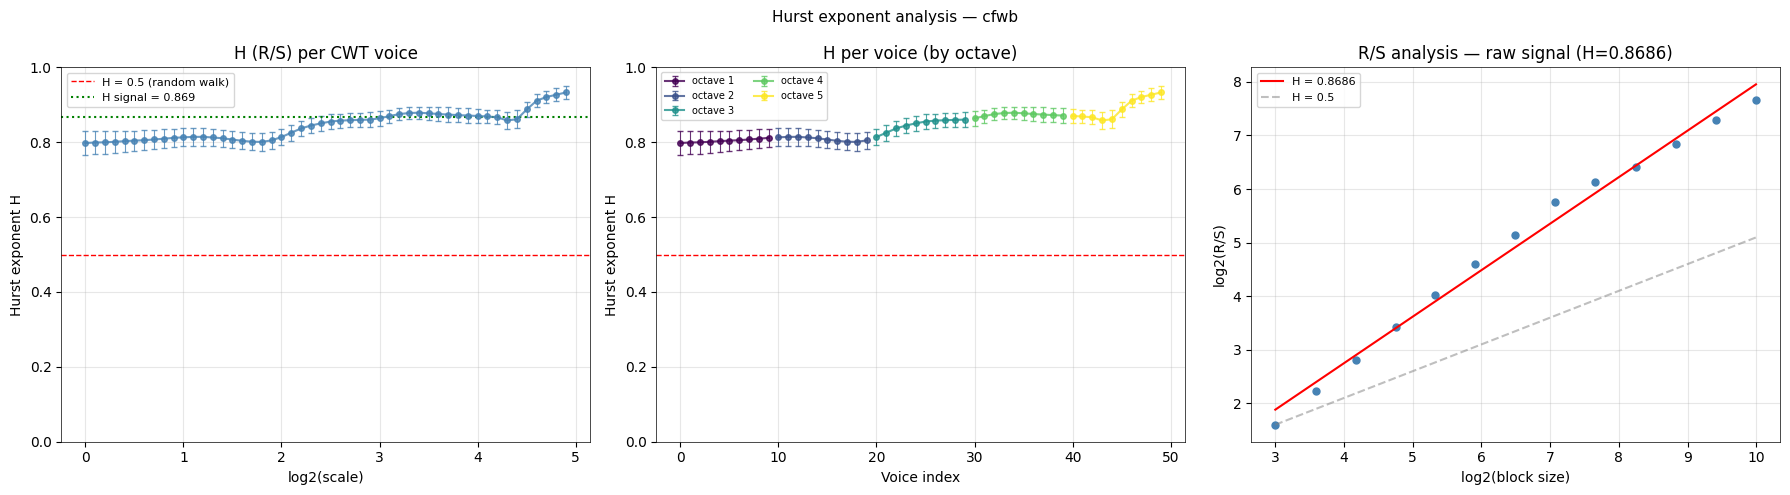

In [143]:
# Cell 23b: Hurst exponent via rescaled range (R/S) analysis — imported from wtmm package

from wtmm.hurst import rescaled_range, hurst_rs

# ── Hurst exponent for each CWT voice ──
H_per_voice = []
H_err = []
for s in range(len(scales_c)):
    voice_signal = np.abs(coeffs_c[s, :])
    H_v, se_v, _, _ = hurst_rs(voice_signal)
    H_per_voice.append(H_v)
    H_err.append(se_v)

H_per_voice = np.array(H_per_voice)
H_err = np.array(H_err)
log2_scales = np.log2(scales_c)

# ── Hurst exponent for the raw signal ──
H_signal, H_signal_se, log_n_sig, log_rs_sig = hurst_rs(segment_c)
print(f'Hurst exponent of raw signal (R/S): H = {H_signal:.4f} +/- {H_signal_se:.4f}')
print(f'H per voice: min={np.nanmin(H_per_voice):.3f}, max={np.nanmax(H_per_voice):.3f}, '
      f'mean={np.nanmean(H_per_voice):.3f}')

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

# (0) H vs voice/scale
ax = axes[0]
ax.errorbar(log2_scales, H_per_voice, yerr=H_err, fmt='o-', markersize=4,
            color='steelblue', ecolor='steelblue', elinewidth=0.8, capsize=2, alpha=0.8)
ax.axhline(0.5, color='red', ls='--', lw=1, label='H = 0.5 (random walk)')
ax.axhline(H_signal, color='green', ls=':', lw=1.5, label=f'H signal = {H_signal:.3f}')
ax.set_xlabel('log2(scale)')
ax.set_ylabel('Hurst exponent H')
ax.set_ylim(0, 1)
ax.set_title('H (R/S) per CWT voice')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (1) H vs voice index (colored by octave)
ax = axes[1]
voice_indices = np.arange(len(scales_c))
colors_oct = plt.cm.viridis(np.linspace(0, 1, n_oct_c))
for o in range(n_oct_c):
    sl = slice(o * n_voice_c, (o + 1) * n_voice_c)
    ax.errorbar(voice_indices[sl], H_per_voice[sl], yerr=H_err[sl],
                fmt='o-', markersize=4, color=colors_oct[o], elinewidth=0.8,
                capsize=2, alpha=0.8, label=f'octave {o+1}')
ax.axhline(0.5, color='red', ls='--', lw=1)
ax.set_xlabel('Voice index')
ax.set_ylabel('Hurst exponent H')
ax.set_ylim(0, 1)
ax.set_title('H per voice (by octave)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# (2) R/S regression for raw signal
ax = axes[2]
if len(log_n_sig) >= 3:
    ax.plot(log_n_sig, log_rs_sig, 'o', markersize=5, color='steelblue')
    fit_line = H_signal * log_n_sig + (log_rs_sig[0] - H_signal * log_n_sig[0])
    p = np.polyfit(log_n_sig, log_rs_sig, 1)
    fit_line = np.polyval(p, log_n_sig)
    ax.plot(log_n_sig, fit_line, '-', color='red', lw=1.5,
            label=f'H = {H_signal:.4f}')
    # Reference slopes
    ax.plot(log_n_sig, 0.5 * log_n_sig + (log_rs_sig[0] - 0.5 * log_n_sig[0]),
            '--', color='grey', alpha=0.5, label='H = 0.5')
    ax.legend(fontsize=8)
ax.set_xlabel('log2(block size)')
ax.set_ylabel('log2(R/S)')
ax.set_title(f'R/S analysis — raw signal (H={H_signal:.4f})')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Hurst exponent analysis — {station}', fontsize=11)
plt.tight_layout()
plt.show()

Total extrema: 12566
Extrema computed in 0.002s
  Scale 0 (a=1.00): 946 extrema
  Scale 10 (a=2.00): 382 extrema
  Scale 20 (a=4.00): 185 extrema
  Scale 30 (a=8.00): 127 extrema
  Scale 40 (a=16.00): 80 extrema
  Scale 49 (a=29.86): 34 extrema


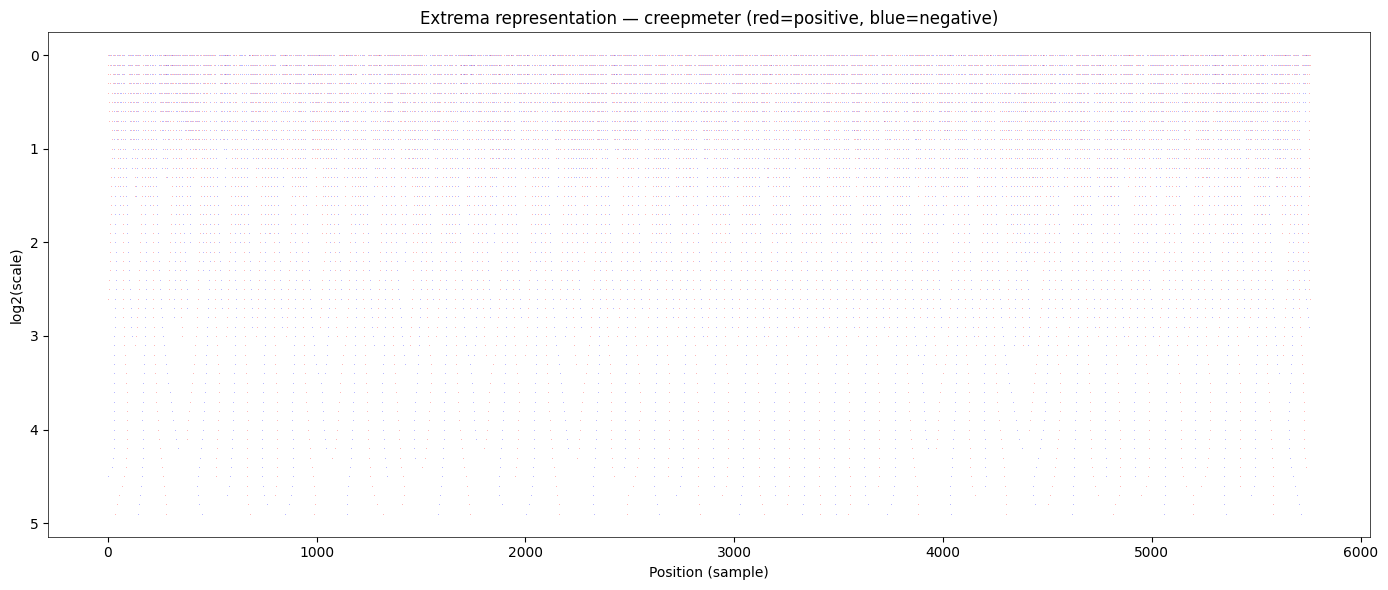

In [144]:
# Cell 24: Extrema detection on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
ea_c, eo_c, ei_c = compute_extrep(coeffs_c, scales_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                   a_min=1.0, valid_ranges=valid_ranges_c,
                                   dx=1.0, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t0:.3f}s')
# Use actual scale count instead of hardcoded indices
sample_indices = [0, n_scales_c // 5, 2 * n_scales_c // 5, 3 * n_scales_c // 5, 4 * n_scales_c // 5, n_scales_c - 1]
for sidx in sample_indices:
    print(f'  Scale {sidx} (a={scales_c[sidx]:.2f}): {len(ea_c[sidx])} extrema')

# Extrema representation plot — vectorized scatter for speed
all_pos = []
all_log2s = []
all_signs = []
for sidx in range(len(ea_c)):
    n = len(ea_c[sidx])
    if n == 0:
        continue
    all_pos.append(ea_c[sidx])
    all_log2s.append(np.full(n, np.log2(scales_c[sidx])))
    all_signs.append(eo_c[sidx] > 0)

all_pos = np.concatenate(all_pos)
all_log2s = np.concatenate(all_log2s)
all_signs = np.concatenate(all_signs)

fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
pos_mask = all_signs
ax.scatter(all_pos[pos_mask], all_log2s[pos_mask], c='red', s=0.1, linewidths=0)
ax.scatter(all_pos[~pos_mask], all_log2s[~pos_mask], c='blue', s=0.1, linewidths=0)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title('Extrema representation — creepmeter (red=positive, blue=negative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Chaining: 0.001s
Delete: 0.013s, deleted 1 chains
ChainMax: 0.012s
Remaining extrema: 12565
Pre-deletion chains: 877
Surviving chains: 877
Deleted chains: 0


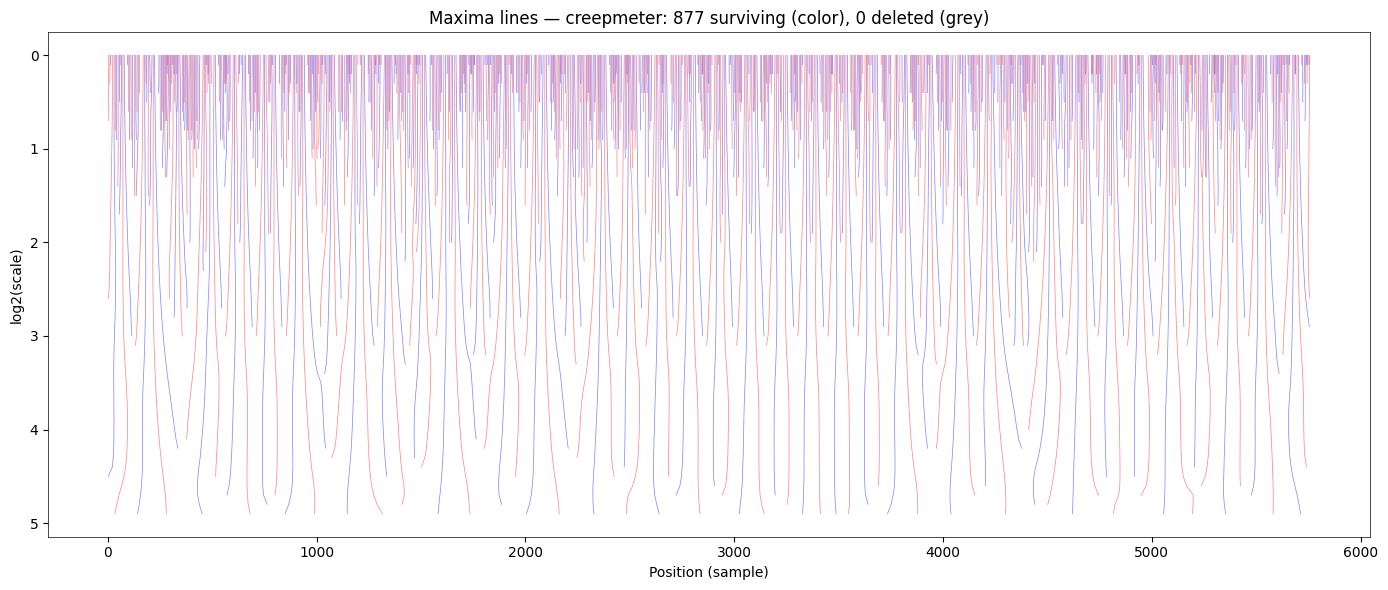

In [145]:
# Cell 25: Chaining + ChainMax on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
cl_c, fl_c = chain_all(ea_c, eo_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs_c, pre_del_ord_c, pre_del_cl_c = save_chain_state(ea_c, eo_c, cl_c)
pre_del_chains_c = trace_chains(pre_del_abs_c, pre_del_ord_c, pre_del_cl_c, scales_c, n_scales_c)

nb_del = chain_delete_all(ea_c, eo_c, ei_c, cl_c, fl_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

chain_max_wrapper(eo_c, cl_c, n_oct=n_oct_c, n_voice=n_voice_c, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')

remaining = sum(len(a) for a in ea_c)
print(f'Remaining extrema: {remaining}')

# Surviving vs deleted chains
post_del_chains_c = trace_chains(ea_c, eo_c, cl_c, scales_c, n_scales_c)

surviving_starts_c = set()
for pos, sv, sign, *_rest in post_del_chains_c:
    surviving_starts_c.add((pos[0], sign))

deleted_chains_c = []
for pos, sv, sign, *_rest in pre_del_chains_c:
    if (pos[0], sign) not in surviving_starts_c:
        deleted_chains_c.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains_c)}')
print(f'Surviving chains: {len(post_del_chains_c)}')
print(f'Deleted chains: {len(deleted_chains_c)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

for pos, sv, sign, *_rest in deleted_chains_c:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

for pos, sv, sign, *_rest in post_del_chains_c:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — creepmeter: {len(post_del_chains_c)} surviving (color), {len(deleted_chains_c)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

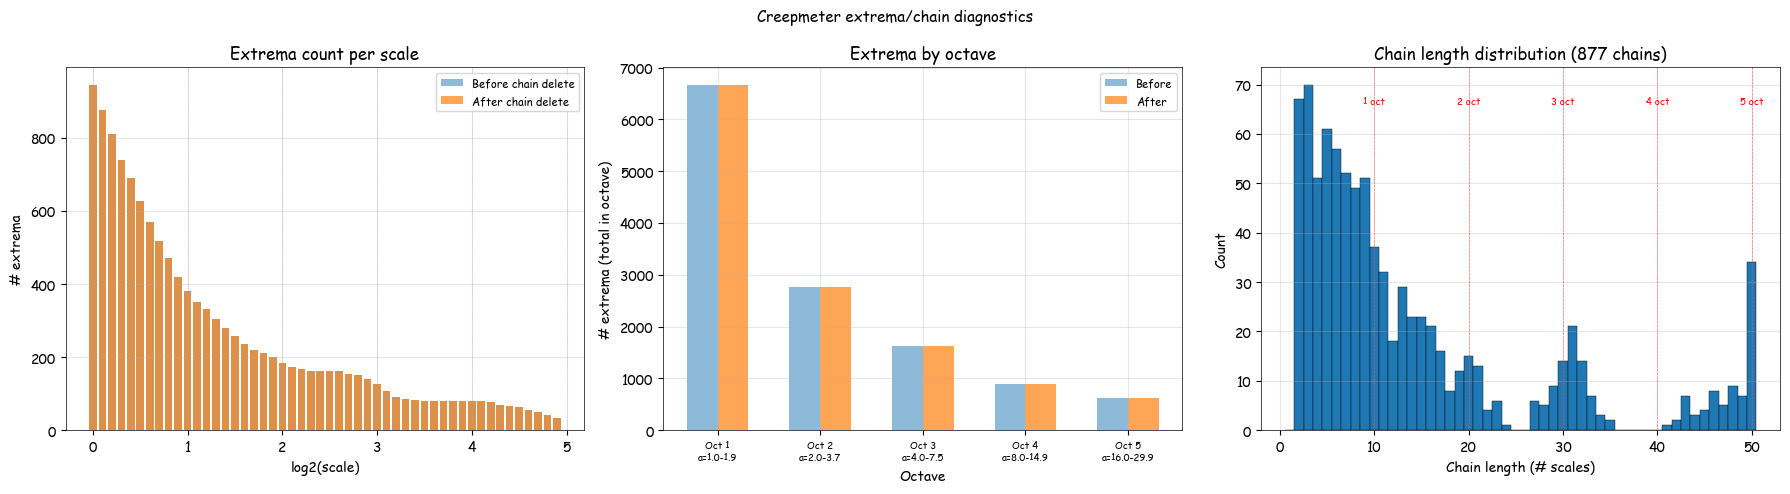

 Scale  log2(a)        a    Pre   Post  Deleted%
--------------------------------------------------
     0     0.00     1.00    946    946      0.0%
     1     0.10     1.07    877    877      0.0%
     2     0.20     1.15    810    810      0.0%
     3     0.30     1.23    740    740      0.0%
     4     0.40     1.32    689    689      0.0%
     5     0.50     1.41    628    628      0.0%
     6     0.60     1.52    571    571      0.0%
     7     0.70     1.62    519    519      0.0%
     8     0.80     1.74    470    470      0.0%
     9     0.90     1.87    420    419      0.2%
    10     1.00     2.00    382    382      0.0%
    11     1.10     2.14    350    350      0.0%
    12     1.20     2.30    332    332      0.0%
    13     1.30     2.46    303    303      0.0%
    14     1.40     2.64    280    280      0.0%
    15     1.50     2.83    257    257      0.0%
    16     1.60     3.03    236    236      0.0%
    17     1.70     3.25    220    220      0.0%
    18     1.80   

In [146]:
# Cell 25b: Extrema count per scale — before and after chain processing
#
# Helps decide where to set regression range (log2_a_min, log2_a_max)
# and whether fine scales are dominated by tidal/noise extrema.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Counts before chain processing (from pre-deletion state)
pre_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    pre_counts[s] = len(pre_del_abs_c[s])

# Counts after chain_delete + chainmax
post_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    post_counts[s] = len(ea_c[s])

log2_scales_c = np.log2(scales_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Bar chart: extrema count per scale
ax = axes[0]
ax.bar(log2_scales_c, pre_counts, width=0.08, alpha=0.5, label='Before chain delete')
ax.bar(log2_scales_c, post_counts, width=0.08, alpha=0.7, label='After chain delete')
ax.set_xlabel('log2(scale)')
ax.set_ylabel('# extrema')
ax.set_title('Extrema count per scale')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# Mark octave boundaries
for o in range(n_oct_c + 1):
    ax.axvline(np.log2(1.0) + o, color='gray', ls=':', lw=0.5, alpha=0.5)

# (1) Extrema count by octave (grouped)
ax = axes[1]
octave_pre = np.zeros(n_oct_c)
octave_post = np.zeros(n_oct_c)
for o in range(n_oct_c):
    for v in range(n_voice_c):
        s = o * n_voice_c + v
        octave_pre[o] += pre_counts[s]
        octave_post[o] += post_counts[s]
x_oct = np.arange(n_oct_c)
ax.bar(x_oct - 0.15, octave_pre, width=0.3, alpha=0.5, label='Before')
ax.bar(x_oct + 0.15, octave_post, width=0.3, alpha=0.7, label='After')
ax.set_xlabel('Octave')
ax.set_ylabel('# extrema (total in octave)')
ax.set_xticks(x_oct)
ax.set_xticklabels([f'Oct {o+1}\na={scales_c[o*n_voice_c]:.1f}-{scales_c[min((o+1)*n_voice_c-1, n_scales_c-1)]:.1f}'
                     for o in range(n_oct_c)], fontsize=7)
ax.set_title('Extrema by octave')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (2) Chain length histogram
ax = axes[2]
chain_lengths = np.array([len(pos) for pos, sv, sign, *_rest in post_del_chains_c])
ax.hist(chain_lengths, bins=np.arange(0.5, chain_lengths.max()+1.5, 1),
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Chain length (# scales)')
ax.set_ylabel('Count')
ax.set_title(f'Chain length distribution ({len(post_del_chains_c)} chains)')
ax.grid(True, alpha=0.3)
# Mark octave lengths
for o in range(1, n_oct_c + 1):
    ax.axvline(o * n_voice_c, color='red', ls='--', lw=0.5, alpha=0.5)
    ax.text(o * n_voice_c, ax.get_ylim()[1]*0.9, f'{o} oct', fontsize=7,
            ha='center', color='red')

plt.suptitle('Creepmeter extrema/chain diagnostics', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Summary table
print(f'{"Scale":>6} {"log2(a)":>8} {"a":>8} {"Pre":>6} {"Post":>6} {"Deleted%":>9}')
print('-' * 50)
for s in range(n_scales_c):
    pct = 100*(1 - post_counts[s]/pre_counts[s]) if pre_counts[s] > 0 else 0
    print(f'{s:6d} {log2_scales_c[s]:8.2f} {scales_c[s]:8.2f} {pre_counts[s]:6d} {post_counts[s]:6d} {pct:8.1f}%')


Scale threshold: 1.1 (log2a >= 0.00, a >= 1.0)
Chains reaching threshold: 877
Chains below threshold:    0


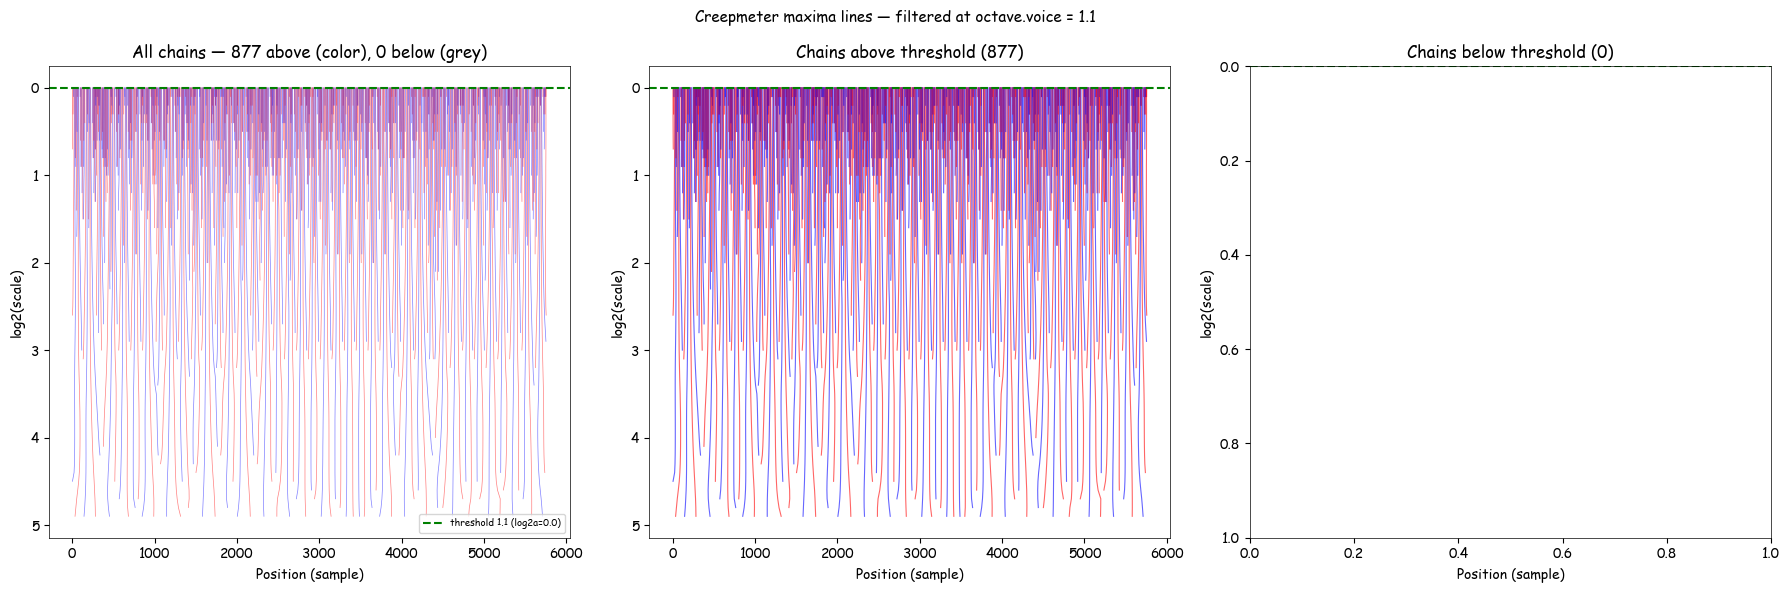


Above threshold: lengths min=2, max=50, median=9


In [147]:
# Cell 25c: Extrema representation filtered by scale range
#
# Visualize only chains that reach above/below a scale threshold.
# Chains reaching coarser scales = large-scale singularities (creep events).
# Chains confined to fine scales = tidal/noise.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ── Configure scale threshold ──
scale_threshold_ov = 1.1  # octave.voice — chains must reach at least this scale
# 1.1 = finest scale, 2.1 = one octave up, 3.1 = two octaves up
# voice goes from 1 to n_voice_c (e.g. 2.6 = octave 2, voice 6)
scale_threshold = ov_to_log2a(scale_threshold_ov)

# Classify chains
chains_above = []  # chains reaching >= threshold
chains_below = []  # chains confined below threshold

for pos, sv, sign, *_rest in post_del_chains_c:
    max_log2a = max(sv)  # coarsest scale reached by this chain
    if max_log2a >= scale_threshold:
        chains_above.append((pos, sv, sign))
    else:
        chains_below.append((pos, sv, sign))

print(f'Scale threshold: {scale_threshold_ov} (log2a >= {scale_threshold:.2f}, a >= {2**scale_threshold:.1f})')
print(f'Chains reaching threshold: {len(chains_above)}')
print(f'Chains below threshold:    {len(chains_below)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) All chains with threshold line
ax = axes[0]
for pos, sv, sign, *_rest in chains_below:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.3, linewidth=0.5)
for pos, sv, sign, *_rest in chains_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)
ax.axhline(scale_threshold, color='green', ls='--', lw=1.5, label=f'threshold {scale_threshold_ov} (log2a={scale_threshold:.1f})')
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'All chains — {len(chains_above)} above (color), {len(chains_below)} below (grey)')
ax.legend(fontsize=7)
ax.invert_yaxis()

# (1) Only chains above threshold
ax = axes[1]
for pos, sv, sign, *_rest in chains_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.6, linewidth=0.8)
ax.axhline(scale_threshold, color='green', ls='--', lw=1.5)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Chains above threshold ({len(chains_above)})')
ax.invert_yaxis()

# (2) Only chains below threshold
ax = axes[2]
for pos, sv, sign, *_rest in chains_below:
    color = 'salmon' if sign > 0 else 'cornflowerblue'
    ax.plot(pos, sv, '-', color=color, alpha=0.4, linewidth=0.5)
ax.axhline(scale_threshold, color='green', ls='--', lw=1.5)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Chains below threshold ({len(chains_below)})')
ax.invert_yaxis()

plt.suptitle(f'Creepmeter maxima lines — filtered at octave.voice = {scale_threshold_ov}', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Chain length stats by group
if chains_above:
    lens_above = [len(pos) for pos, sv, sign, *_rest in chains_above]
    print(f'\nAbove threshold: lengths min={min(lens_above)}, max={max(lens_above)}, '
          f'median={np.median(lens_above):.0f}')
if chains_below:
    lens_below = [len(pos) for pos, sv, sign, *_rest in chains_below]
    print(f'Below threshold: lengths min={min(lens_below)}, max={max(lens_below)}, '
          f'median={np.median(lens_below):.0f}')


Total chains: 877
Above threshold (log2a >= 0.0): 877
Below threshold: 0


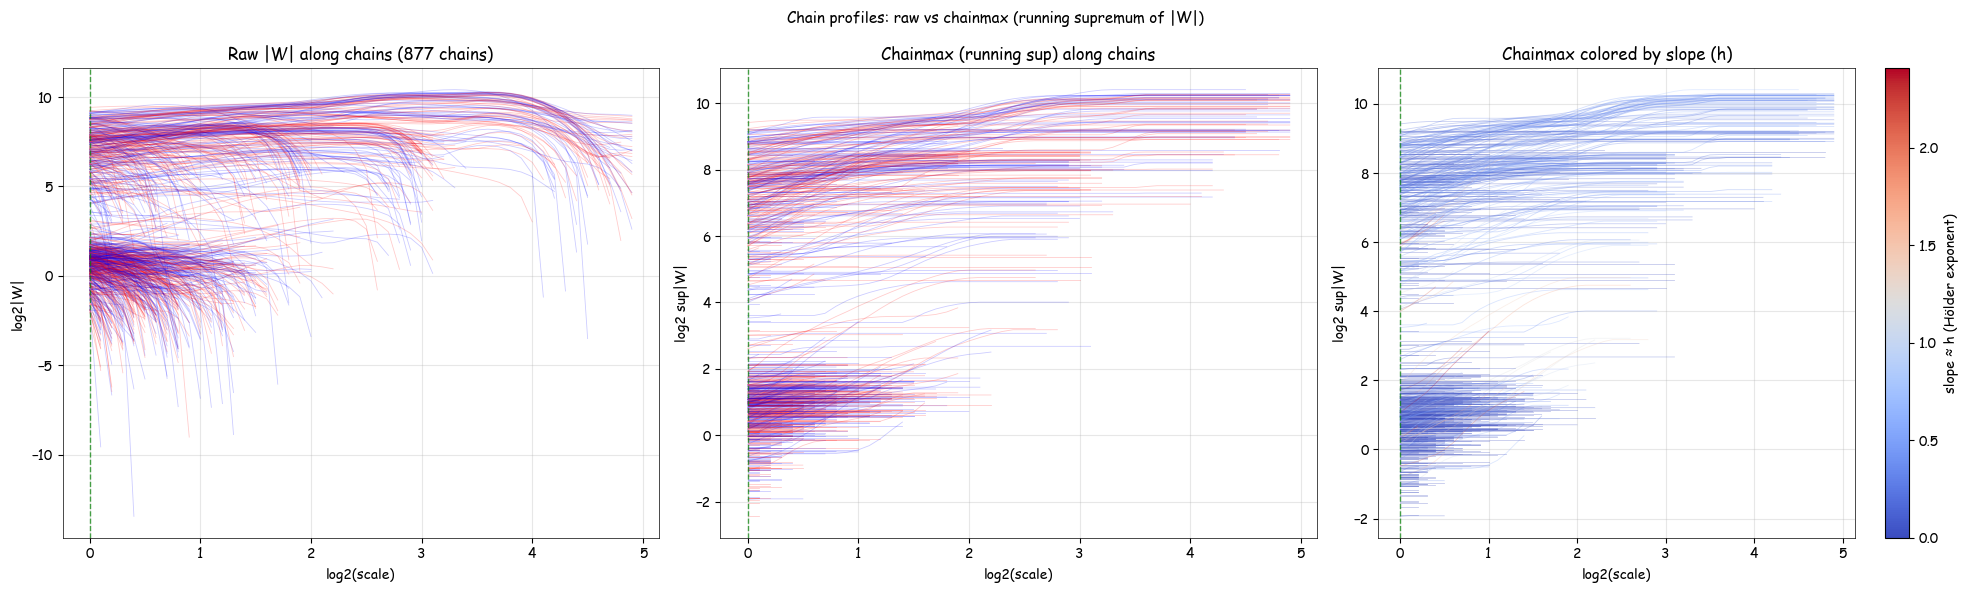


Chainmax slope (h) stats: mean=0.162, median=0.000, std=0.310, range=[-0.000, 2.407]


In [148]:
# Cell 25d: Chain profiles — chainmax view (running supremum of |W|)
#
# For each chain, at each scale a we display sup{|W(a')| : a' <= a}.
# This is the chainmax operation: replacing each coefficient with the
# running maximum from finer scales, which removes smooth perturbations
# and isolates true singularities.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ── Trace chains, collecting raw CWT ordinates + running supremum ──
chain_profiles = []  # (log2_scales, log2_raw, log2_sup, sign, max_log2a)
for fi in range(len(ea_c[0])):
    log2_sc = []
    raw_vals = []
    cs = 0
    ci = fi
    while cs < n_scales_c and ci != -1:
        pos = ea_c[cs][ci]
        # Look up raw CWT coefficient at this position and scale
        idx = int(round(pos))
        if 0 <= idx < coeffs_c.shape[1]:
            raw_val = abs(coeffs_c[cs, idx])
        else:
            raw_val = 0.0
        if raw_val > 0:
            raw_vals.append(raw_val)
            log2_sc.append(np.log2(scales_c[cs]))
        ci = cl_c[cs][ci]
        cs += 1
    if len(log2_sc) > 1:
        # Compute running supremum from fine to coarse
        sup_vals = np.maximum.accumulate(raw_vals)
        sign = 1 if eo_c[0][fi] > 0 else -1
        chain_profiles.append((
            log2_sc,
            np.log2(raw_vals),
            np.log2(sup_vals),
            sign,
            max(log2_sc)
        ))

# Filter by scale threshold (from Cell 25c)
profiles_above = [p for p in chain_profiles if p[4] >= scale_threshold]
profiles_below = [p for p in chain_profiles if p[4] < scale_threshold]

print(f'Total chains: {len(chain_profiles)}')
print(f'Above threshold (log2a >= {scale_threshold}): {len(profiles_above)}')
print(f'Below threshold: {len(profiles_below)}')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Raw CWT coefficients along chains
ax = axes[0]
for log2_sc, log2_raw, log2_sup, sign, _ in profiles_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(log2_sc, log2_raw, '-', color=color, alpha=0.2, linewidth=0.6)
ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2|W|')
ax.set_title(f'Raw |W| along chains ({len(profiles_above)} chains)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (1) Chainmax'd (running supremum)
ax = axes[1]
for log2_sc, log2_raw, log2_sup, sign, _ in profiles_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.2, linewidth=0.6)
ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title(f'Chainmax (running sup) along chains')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (2) Chainmax'd colored by slope (Hölder exponent h)
ax = axes[2]
slopes = []
for log2_sc, log2_raw, log2_sup, sign, _ in profiles_above:
    if len(log2_sc) >= 3:
        slope, _ = np.polyfit(log2_sc, log2_sup, 1)
        slopes.append(slope)
        color = plt.cm.coolwarm((slope - 0) / 2.0)
        ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.3, linewidth=0.6)

if slopes:
    sm = plt.cm.ScalarMappable(cmap='coolwarm',
                                norm=plt.Normalize(vmin=min(slopes), vmax=max(slopes)))
    plt.colorbar(sm, ax=ax, label='slope ≈ h (Hölder exponent)')

ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title(f'Chainmax colored by slope (h)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

plt.suptitle('Chain profiles: raw vs chainmax (running supremum of |W|)', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

if slopes:
    slopes = np.array(slopes)
    print(f'\nChainmax slope (h) stats: mean={slopes.mean():.3f}, median={np.median(slopes):.3f}, '
          f'std={slopes.std():.3f}, range=[{slopes.min():.3f}, {slopes.max():.3f}]')

Chains above threshold: 1350 original → 760 after trimming
Mean chain length: 15.5 → 14.4 scales
Total scale points trimmed: 5593
Extrema for PF: 10933


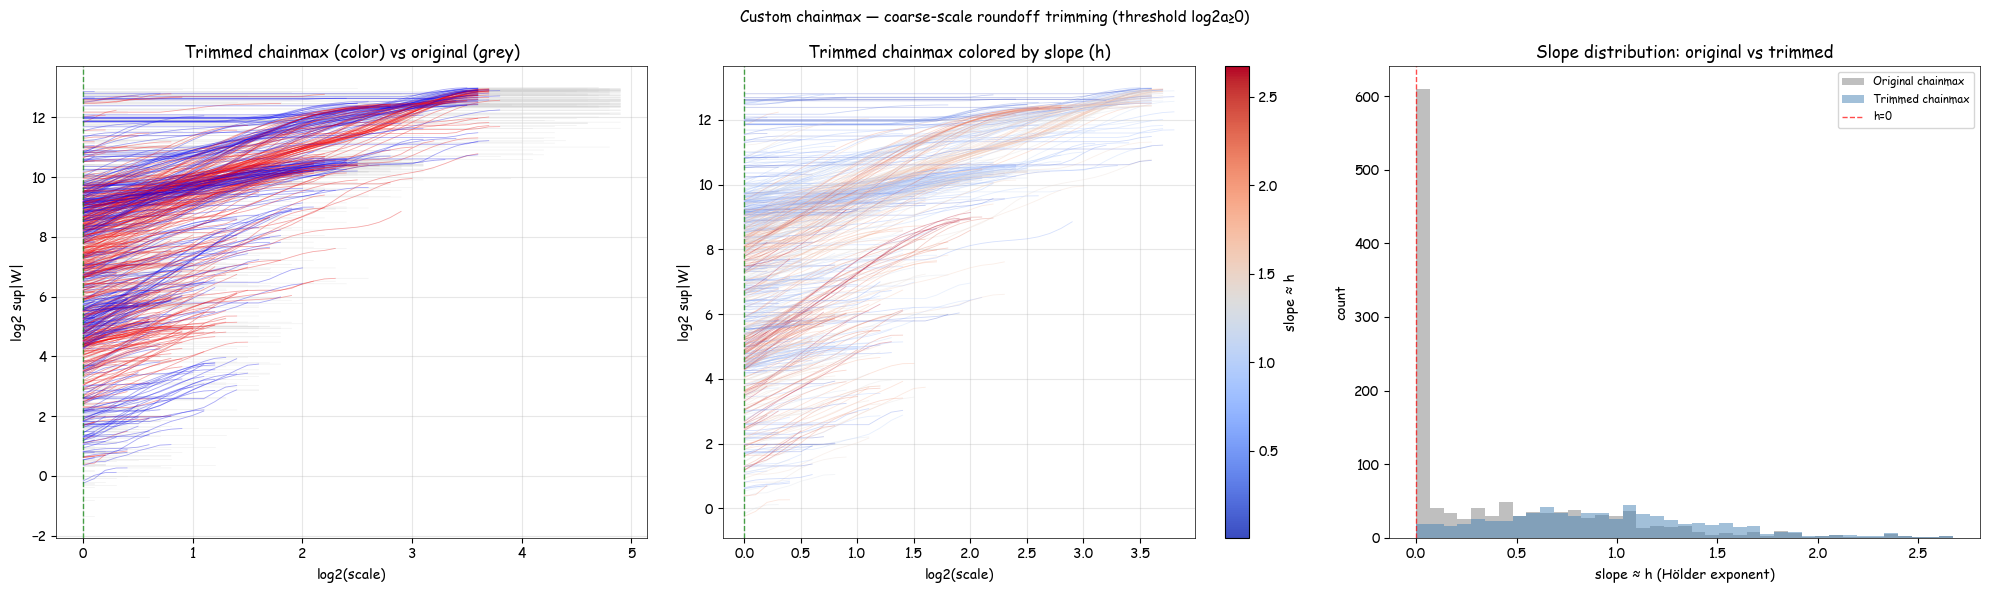


Trimmed slope stats: mean=0.930, median=0.890, std=0.534, range=[0.010, 2.673]
Chains with |h| < 0.1: 31 (4.5%)


In [ ]:
# Cell 25e: Custom chainmax — discard coarse-scale roundoff artifacts
#
# Standard chainmax walks fine→coarse keeping a running sup.
# Problem: at coarse scales, the CWT value can be dominated by roundoff
# or smooth components, giving |W(coarse)| < sup|W(fine)|. Standard
# chainmax replaces these with the sup, creating flat plateaus (h≈0).
#
# Fix: walk coarse→fine. At the coarsest end, if |W| < sup from finer
# scales, DISCARD that scale point entirely (don't include in PF).
# Once we reach the scale where the sup was achieved, resume normal
# chainmax from there downward.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ── Custom chainmax: trim coarse-scale roundoff ──
chain_profiles_trimmed = []  # (log2_scales, log2_sup, sign, max_log2a)

for fi in range(len(ea_c[0])):
    # First pass: collect raw |W| along chain (fine→coarse)
    chain_data = []  # list of (scale_idx, array_idx, log2_scale, raw_abs_val)
    cs = 0
    ci = fi
    while cs < n_scales_c and ci != -1:
        pos = ea_c[cs][ci]
        idx = int(round(pos))
        if 0 <= idx < coeffs_c.shape[1]:
            raw_val = abs(coeffs_c[cs, idx])
        else:
            raw_val = 0.0
        if raw_val > 0:
            chain_data.append((cs, ci, np.log2(scales_c[cs]), raw_val))
        ci = cl_c[cs][ci]
        cs += 1

    if len(chain_data) < 2:
        continue

    # Compute running sup from fine→coarse
    raw_vals = np.array([d[3] for d in chain_data])
    sup_fine_to_coarse = np.maximum.accumulate(raw_vals)

    # Find where the global sup is first achieved
    global_sup = sup_fine_to_coarse[-1]
    sup_scale_idx = len(raw_vals) - 1
    for k in range(len(raw_vals)):
        if raw_vals[k] >= global_sup:
            sup_scale_idx = k
            break

    # Walk from coarsest: trim scales where |W| < sup from finer scales
    # i.e., discard the coarse tail where the chain is just plateau
    trim_from = len(chain_data)  # keep everything by default
    for k in range(len(chain_data) - 1, sup_scale_idx, -1):
        if raw_vals[k] < sup_fine_to_coarse[k - 1]:
            trim_from = k  # discard this and coarser
        else:
            break  # found a scale where |W| exceeds prior sup — stop trimming

    # Trimmed chain: fine scales up to trim point
    trimmed = chain_data[:trim_from]
    if len(trimmed) < 2:
        continue

    trimmed_vals = np.array([d[3] for d in trimmed])
    trimmed_sup = np.maximum.accumulate(trimmed_vals)
    trimmed_log2s = [d[2] for d in trimmed]
    sign = 1 if eo_c[0][fi] > 0 else -1

    chain_profiles_trimmed.append((
        trimmed_log2s,
        np.log2(trimmed_vals),
        np.log2(trimmed_sup),
        sign,
        max(trimmed_log2s),
        # Also store (scale_idx, array_idx) for building filtered PF input
        [(d[0], d[1]) for d in trimmed]
    ))

# Filter by scale threshold
profiles_trimmed_above = [p for p in chain_profiles_trimmed if p[4] >= scale_threshold]

# Stats
n_orig_above = len([p for p in chain_profiles if p[4] >= scale_threshold])  # from Cell 25d
n_trimmed_above = len(profiles_trimmed_above)
orig_lengths = [len(p[0]) for p in chain_profiles if p[4] >= scale_threshold]
trimmed_lengths = [len(p[0]) for p in profiles_trimmed_above]

print(f'Chains above threshold: {n_orig_above} original → {n_trimmed_above} after trimming')
if orig_lengths and trimmed_lengths:
    print(f'Mean chain length: {np.mean(orig_lengths):.1f} → {np.mean(trimmed_lengths):.1f} scales')
    n_trimmed_pts = sum(o - t for o, t in zip(orig_lengths, trimmed_lengths) if o > t)
    print(f'Total scale points trimmed: {n_trimmed_pts}')

# ── Build filtered ordinates for PF (trimmed chains above threshold) ──
trimmed_members = [set() for _ in range(n_scales_c)]
for log2_sc, log2_raw, log2_sup, sign, max_l2a, member_indices in profiles_trimmed_above:
    for cs, ci in member_indices:
        trimmed_members[cs].add(ci)

eo_trimmed = []
for s in range(n_scales_c):
    indices = sorted(trimmed_members[s])
    if indices:
        # Use chainmax'd values: running sup of raw |W|
        # Recompute per-extremum: for each extremum in a chain, the sup up to that scale
        eo_trimmed.append(np.array([eo_c[s][i] for i in indices]))
    else:
        eo_trimmed.append(np.array([], dtype=np.float64))

n_ext_trimmed = sum(len(a) for a in eo_trimmed)
print(f'Extrema for PF: {n_ext_trimmed}')

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Original chainmax profiles (from 25d) vs trimmed
ax = axes[0]
for log2_sc, log2_raw, log2_sup, sign, _ in [p for p in chain_profiles if p[4] >= scale_threshold]:
    ax.plot(log2_sc, log2_sup, '-', color='lightgrey', alpha=0.3, linewidth=0.5)
for log2_sc, log2_raw, log2_sup, sign, _, _ in profiles_trimmed_above:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.3, linewidth=0.6)
ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title('Trimmed chainmax (color) vs original (grey)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (1) Trimmed profiles colored by slope
ax = axes[1]
slopes_trimmed = []
for log2_sc, log2_raw, log2_sup, sign, _, _ in profiles_trimmed_above:
    if len(log2_sc) >= 3:
        slope, _ = np.polyfit(log2_sc, log2_sup, 1)
        slopes_trimmed.append(slope)
        color = plt.cm.coolwarm((slope - 0) / 2.0)
        ax.plot(log2_sc, log2_sup, '-', color=color, alpha=0.3, linewidth=0.6)

if slopes_trimmed:
    sm = plt.cm.ScalarMappable(cmap='coolwarm',
                                norm=plt.Normalize(vmin=min(slopes_trimmed), vmax=max(slopes_trimmed)))
    plt.colorbar(sm, ax=ax, label='slope ≈ h')

ax.set_xlabel('log2(scale)')
ax.set_ylabel('log2 sup|W|')
ax.set_title('Trimmed chainmax colored by slope (h)')
ax.axvline(scale_threshold, color='green', ls='--', lw=1, alpha=0.7)
ax.grid(True, alpha=0.3)

# (2) Histogram: slope comparison original vs trimmed
ax = axes[2]
if len(slopes) > 0 and len(slopes_trimmed) > 0:  # slopes from Cell 25d
    bins = np.linspace(min(min(slopes), min(slopes_trimmed)),
                       max(max(slopes), max(slopes_trimmed)), 40)
    ax.hist(slopes, bins=bins, alpha=0.5, color='grey', label='Original chainmax')
    ax.hist(slopes_trimmed, bins=bins, alpha=0.5, color='steelblue', label='Trimmed chainmax')
    ax.axvline(0, color='red', ls='--', lw=1, alpha=0.7, label='h=0')
    ax.set_xlabel('slope ≈ h (Hölder exponent)')
    ax.set_ylabel('count')
    ax.set_title('Slope distribution: original vs trimmed')
    ax.legend(fontsize=8)

plt.suptitle(f'Custom chainmax — coarse-scale roundoff trimming (threshold log2a≥{scale_threshold})',
             fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

if slopes_trimmed:
    slopes_trimmed = np.array(slopes_trimmed)
    print(f'\nTrimmed slope stats: mean={slopes_trimmed.mean():.3f}, '
          f'median={np.median(slopes_trimmed):.3f}, '
          f'std={slopes_trimmed.std():.3f}, range=[{slopes_trimmed.min():.3f}, {slopes_trimmed.max():.3f}]')
    near_zero = np.sum(np.abs(slopes_trimmed) < 0.1)
    print(f'Chains with |h| < 0.1: {near_zero} ({100*near_zero/len(slopes_trimmed):.1f}%)')

Scale threshold: log2(a) >= 0
Extrema: 21055 total → 10933 after trimming (51.9%)
Partition function computed in 0.004s, up to scale index 38


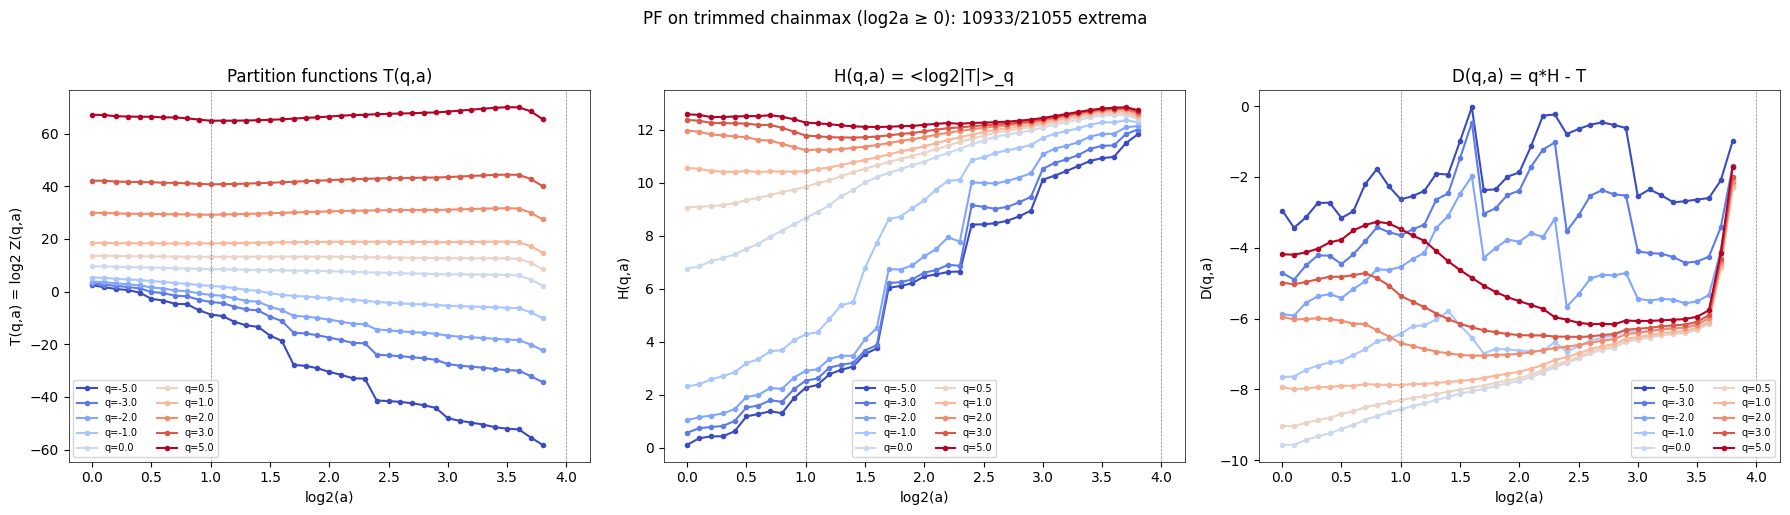

Gray dashed lines show regression range [log2(a)=1 to 4]


In [ ]:
# Cell 26: Partition functions on creepmeter data — trimmed chainmax
#
# Uses eo_trimmed from Cell 25e: coarse-scale roundoff artifacts discarded,
# only chains above scale_threshold, only surviving scale points.

q_list_c = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

n_ext_trimmed = sum(len(a) for a in eo_trimmed)
n_total = sum(len(eo_c[s]) for s in range(n_scales_c))
print(f'Scale threshold: log2(a) >= {scale_threshold}')
print(f'Extrema: {n_total} total → {n_ext_trimmed} after trimming ({100*n_ext_trimmed/n_total:.1f}%)')

t0 = time.time()
pf_c = compute_partition_function(eo_trimmed, n_oct=n_oct_c, n_voice=n_voice_c,
                                  a_min=1.0, q_list=q_list_c)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf_c["index_max"]}')

# Plot T(q,a), H(q,a), D(q,a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes.flatten():
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_ac = pf_c['log2_a']
valid_c = slice(0, pf_c['index_max'] + 1)
colors_c = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_c)))

ax = axes[0]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_T(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(ov_to_log2a(reg_min_ov) if 'reg_min_ov' in dir() else 1.0, color='gray', ls='--', lw=0.5)
ax.axvline(ov_to_log2a(reg_max_ov) if 'reg_max_ov' in dir() else 4.0, color='gray', ls='--', lw=0.5)

ax = axes[1]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_H(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(ov_to_log2a(reg_min_ov) if 'reg_min_ov' in dir() else 1.0, color='gray', ls='--', lw=0.5)
ax.axvline(ov_to_log2a(reg_max_ov) if 'reg_max_ov' in dir() else 4.0, color='gray', ls='--', lw=0.5)

ax = axes[2]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_D(pf_c, i, q)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(ov_to_log2a(reg_min_ov) if 'reg_min_ov' in dir() else 1.0, color='gray', ls='--', lw=0.5)
ax.axvline(ov_to_log2a(reg_max_ov) if 'reg_max_ov' in dir() else 4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'PF on trimmed chainmax (log2a ≥ {scale_threshold}): '
             f'{n_ext_trimmed}/{n_total} extrema', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')

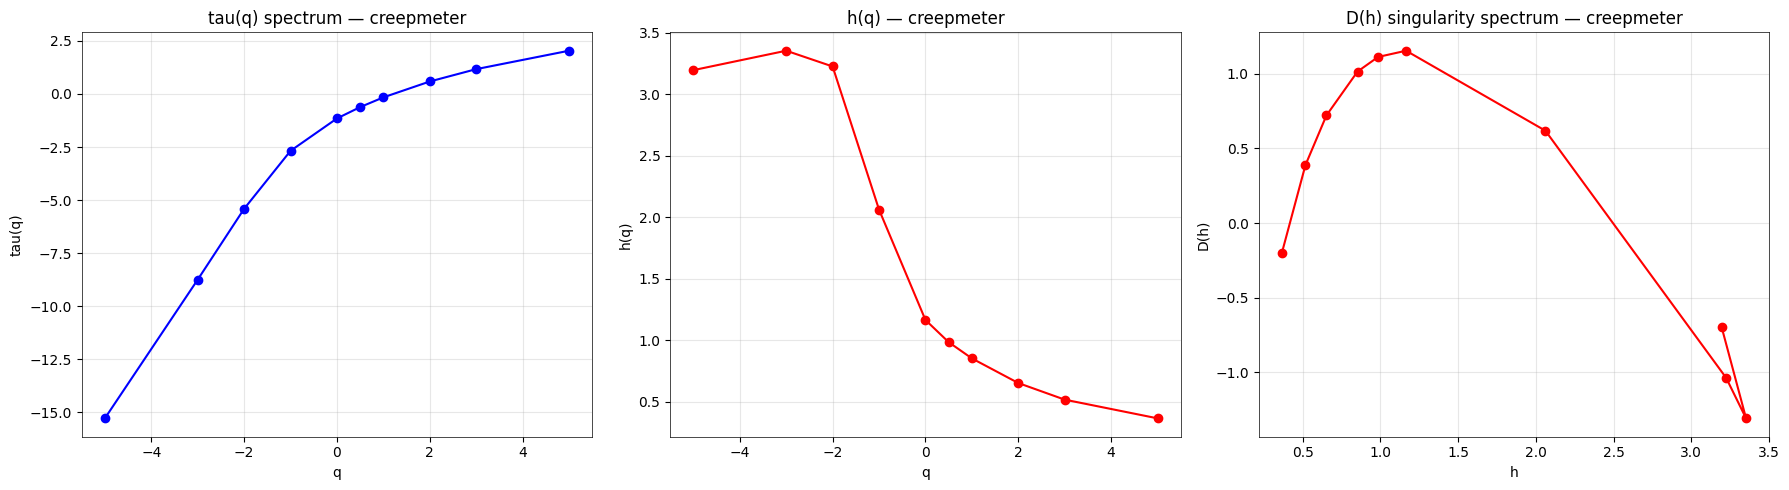


Creepmeter WTMM multifractal analysis:
q	 tau(q)		 h(q)		 D(q)
 -5.0	 -15.2778	   3.1945	  -0.6947
 -3.0	  -8.7474	   3.3523	  -1.3095
 -2.0	  -5.4106	   3.2244	  -1.0381
 -1.0	  -2.6806	   2.0617	   0.6190
  0.0	  -1.1552	   1.1656	   1.1552
  0.5	  -0.6205	   0.9856	   1.1133
  1.0	  -0.1619	   0.8536	   1.0155
  2.0	   0.5856	   0.6536	   0.7216
  3.0	   1.1670	   0.5186	   0.3889
  5.0	   2.0346	   0.3668	  -0.2005


In [ ]:
# Cell 27: tau(q), h(q), D(h) spectra for creepmeter data
# Adjust log2_a_min and log2_a_max based on visual inspection of Cell 14

reg_min_ov = 2.7  # octave.voice — regression range start
reg_max_ov = 4.7  # octave.voice — regression range end
spectra_c = compute_spectra(pf_c, log2_a_min=ov_to_log2a(reg_min_ov), log2_a_max=ov_to_log2a(reg_max_ov))
print(f'Regression range: {reg_min_ov} to {reg_max_ov} (log2a: {ov_to_log2a(reg_min_ov):.2f} to {ov_to_log2a(reg_max_ov):.2f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'ro-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'ro-', markersize=6)
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum — creepmeter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCreepmeter WTMM multifractal analysis:')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_c['q_list']):
    print(f'{q:5.1f}\t {spectra_c["tau_q"][i]:8.4f}\t {spectra_c["h_q"][i]:8.4f}\t {spectra_c["D_q"][i]:8.4f}')

In [ ]:
# Cell 28: Decimate creepmeter to hourly — 6 phase-shifted sub-signals
#
# 10-min sampling → every 6th sample = 1-hour sampling.
# Offsets 0..5 give 6 independent hourly series (like 6 "realizations").
# This is analogous to DemoWTMM1DDevilStair's 50 random realizations,
# except our "realizations" are phase offsets of the same physical process.

DECIM = 6  # decimation factor (10min × 6 = 60min = 1 hour)

# Build 6 hourly sub-signals
hourly_signals = []
for offset in range(DECIM):
    sub = segment_c[offset::DECIM].copy()
    hourly_signals.append(sub)
    
min_len = min(len(s) for s in hourly_signals)
print(f'Original signal: {len(segment_c)} samples at 10-min')
print(f'Decimated: {DECIM} sub-signals of {min_len} samples at 1-hour')
print(f'  (duration: {min_len / 24:.1f} days = {min_len / 24 / 365.25:.2f} years)')

# Plot all 6 overlaid
fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
for offset in range(DECIM):
    t_hr = np.arange(len(hourly_signals[offset])) / 24  # days
    ax.plot(t_hr, hourly_signals[offset], alpha=0.6, linewidth=0.5,
            label=f'offset {offset}')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Displacement (mm)')
ax.set_title(f'6 hourly sub-signals (decimation factor {DECIM})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: PF accumulation — imported from wtmm package
# Matching LastWave's "pf add" (PFStandardAddition)

from wtmm.partition import pf_standard_addition, pf_copy

print('pf_standard_addition() and pf_copy() imported from wtmm.partition.')

In [ ]:
# Cell 29: Full WTMM pipeline on each hourly sub-signal, accumulate with pf add
#
# Mirrors DemoWTMM1DDevilStair loop:
#   foreach i 0:nrepeat-1 {
#       cwtd w amin omax nv wavelet -b 'mir'
#       extrema w
#       chainmax w.extrep 1
#       if (i == 0) { pft = [pf wtmm w.extrep qlist] }
#       else { pft = [pf add pft [pf wtmm w.extrep qlist]] }
#   }

# Parameters — match the single-signal creepmeter analysis
n_oct_h = n_oct_c      # same octave count
n_voice_h = n_voice_c  # same voices per octave
a_min_h = 1.0
wavelet_h = 'g2'
expo_h = -1.0
q_list_h = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

pf_accumulated = None
t_total = time.time()

for offset in range(DECIM):
    sig = hourly_signals[offset][:min_len]  # trim to same length
    t0 = time.time()
    
    # 1. CWT
    coeffs_h, scales_h, vr_h = cwtd_batched(sig, a_min=a_min_h, n_oct=n_oct_h,
                                              n_voice=n_voice_h, wavelet_name=wavelet_h,
                                              expo=expo_h)
    
    # 2. Extrema
    ea_h, eo_h, ei_h = compute_extrep(coeffs_h, scales_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                       a_min=a_min_h, valid_ranges=vr_h,
                                       dx=1.0, x0=0.0, epsilon=1e-6)
    
    # 3. Chain + delete + chainmax
    cl_h, fl_h = chain_all(ea_h, eo_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_delete_all(ea_h, eo_h, ei_h, cl_h, fl_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_max_wrapper(eo_h, cl_h, n_oct=n_oct_h, n_voice=n_voice_h, a_min=a_min_h, expo=1.0)
    
    # 4. Partition function
    pf_h = compute_partition_function(eo_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                      a_min=a_min_h, q_list=q_list_h)
    
    # 5. Accumulate
    if pf_accumulated is None:
        pf_accumulated = pf_copy(pf_h)
    else:
        pf_standard_addition(pf_accumulated, pf_h)
    
    n_ext_h = sum(len(a) for a in ea_h)
    t1 = time.time()
    print(f'  Offset {offset}: {len(sig)} samples, {n_ext_h} extrema after pruning, '
          f'index_max={pf_h["index_max"]}, {t1-t0:.2f}s')

print(f'\nTotal: {time.time() - t_total:.2f}s')
print(f'Accumulated {pf_accumulated["signal_number"]} realizations')
print(f'Combined index_max: {pf_accumulated["index_max"]}')

In [ ]:
# Cell 30: Intensive-mode partition functions — T, H, D vs log2(a)
#
# Intensive mode divides logSTq and sTqLogT_sTq by signalNumber,
# giving the *average* across realizations. This reduces noise in
# the scaling plots and gives more reliable regression slopes.

log2_ah = pf_accumulated['log2_a']
valid_h = slice(0, pf_accumulated['index_max'] + 1)
q_arr = pf_accumulated['q_list']
colors_h = plt.cm.coolwarm(np.linspace(0, 1, len(q_arr)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# T(q,a) — intensive
ax = axes[0]
for i, q in enumerate(q_arr):
    y = pf_get_T(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) intensive')
ax.set_title(f'Intensive T(q,a) — {pf_accumulated["signal_number"]} hourly sub-signals')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a) — intensive
ax = axes[1]
for i, q in enumerate(q_arr):
    y = pf_get_H(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a) intensive')
ax.set_title('Intensive H(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a) — intensive
ax = axes[2]
for i, q in enumerate(q_arr):
    y = pf_get_D(pf_accumulated, i, q, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a) intensive')
ax.set_title('Intensive D(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'Hourly decimated creepmeter — intensive mode ({DECIM} realizations)', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show default regression range [log2(a)=1 to 4]. Adjust below if needed.')

In [ ]:
# Cell 31: tau(q), h(q), D(h) spectra — intensive mode, compared to single-signal extensive
#
# The intensive mode should give smoother, more reliable spectra because it
# averages the log-partition functions across 6 realizations before regression.

reg_min_ov_h = 2.1  # octave.voice — regression range start
reg_max_ov_h = 5.1  # octave.voice — regression range end
spectra_h = compute_spectra(pf_accumulated, log2_a_min=ov_to_log2a(reg_min_ov_h), log2_a_max=ov_to_log2a(reg_max_ov_h), mode='intensive')
print(f'Regression range: {reg_min_ov_h} to {reg_max_ov_h} (log2a: {ov_to_log2a(reg_min_ov_h):.2f} to {ov_to_log2a(reg_max_ov_h):.2f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# tau(q)
ax = axes[0]
ax.plot(spectra_h['q_list'], spectra_h['tau_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# h(q)
ax = axes[1]
ax.plot(spectra_h['q_list'], spectra_h['h_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q)')
ax.legend()
ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
ax.plot(spectra_h['h_q'], spectra_h['D_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Intensive (hourly decimated) vs Extensive (single signal)', y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(f'\nIntensive WTMM ({DECIM} hourly sub-signals):')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_h['q_list']):
    print(f'{q:5.1f}\t {spectra_h["tau_q"][i]:8.4f}\t {spectra_h["h_q"][i]:8.4f}\t {spectra_h["D_q"][i]:8.4f}')